# Development notebook (everything together)
## `calmly` calmly aligns optical cavities using machine learning.
This is the main notebook for the initial development of key components of `calmly`. Not for public distribution.

In [1]:
import numpy as np
import scipy
import cv2 as cv
import matplotlib.pyplot as plt
import finesse
import gymnasium as gym
from gymnasium import spaces
import torch
import pickle
import tqdm
from enum import Enum

# stable_baselines3
from stable_baselines3 import PPO, DQN, SAC
from stable_baselines3.ppo import MultiInputPolicy as PPOMultiInputPolicy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
from stable_baselines3.common.callbacks import BaseCallback

# Imitation Learning
from imitation.data.types import DictObs, Transitions
from imitation.algorithms.bc import BC

## Cavity and motor simulators

In [2]:
class CavityAlignment():
    DEFAULT_SCAN_RANGE_IN_FSRS = 2.1 # scan range expressed in the units of one FSR
    DEFAULT_MAXTEM = 5 # maximum order of TEM modes to model. 
    def __init__(self,
                 finesse_model,
                 cavity,
                 steering_mirror_1, steering_mirror_2,
                 scan_readout,
                 scan_actuator,
                 numpy_rng : np.random._generator.Generator = None
                ):
        """
        Parameters
        ----------
        finesse_model : finesse.model.Model
            Finesse model of the system, must at least include the cavity, two steering mirrors, and one readout.
        cavity : finesse.components.cavity.Cavity
            The cavity to be aligned (must be part of `finesse_model`)
        steering_mirror_1, steering_mirror_2 : finesse.components.beamsplitter.Beamsplitter
            Steering mirrors to align and translate the beam
        scan_readout : finesse.detectors.powerdetector.PowerDetector
            Finesse detector used to produce the cavity scans
        scan_actuator : finesse.components.laser.Laser or finesse.components.beamsplitter.Beamsplitter or finesse.components.mirror.Mirror
            Finesse component (Laser or mirror-like) that is being actuated on to produce cavity scans.
        numpy_rng : numpy.random._generator.Generator
            Numpy random number generator to use. If `None` (default), a new one will be initialised.
        """
        self.m   = finesse_model
        self.cav = cavity
        self.sm1 = steering_mirror_1
        self.sm2 = steering_mirror_2
        self.r   = scan_readout
        self.act = scan_actuator
        self.steering_motors = {}

        if self.m.Nhoms == 1:
            """If the current maxtem is zero, we should switch to the default value"""
            self.set_maxtem()

        if numpy_rng is None:
            self.numpy_rng = np.random.default_rng()
        else:
            self.numpy_rng = numpy_rng
        
        self.settings = {
            'noise_mean' : 1.0e-3,
            'noise_std' : 3.0e-4,
            'signal_norm_level' : 1.2 # normalisation factor with respect to the max readout value
        }
        
        # signal reference
        self.signal_ref = self.get_signal_reference(self.settings['signal_norm_level'])
        
        self.misalignment_axes = {}

    @classmethod
    def two_mirror_cavity(cls,
                          Lcav = 1.0,
                          Rc = (np.inf, 3.0),
                          Refl = (0.98, 0.98),
                          Loss = (0.0, 0.0),
                          StSp = (1.0, 2.0),
                          maxtem = None,
                          numpy_rng = None
                         ):
        """
        Alternative constructor which automatically creates a simple predefined Finesse model of a 2-mirror optical cavity
        with a laser and two steering mirrors (SM1 and SM2) at given distances before the cavity, each at 45 deg angle of incidence.
        
        Parameters
        ----------
        Lcav : float
            Cavity length in metres.
        Rc : tuple of float
            2-tuple of the radii of curvature (RoCs) of the input coupler (IC) and the output coupler (OC) of the cavity.
            Default is (np.inf, 3.0).
        Refl : tuple of float
            2-tuple of reflection coefficients of IC and OC. Default is (0.98, 0.98).
        Loss : tuple of float
            2-tuple of loss coefficients of IC and OC. Default is (0.0, 0.0).
        StSp : tuple of float
            2-tuple containing the distance between steering mirror 1 (SM1) and SM2 as the zeroth element
            and the distance between SM2 and IC as the last element.
            Default is (1.0, 2.0).
        maxtem : int
            Maximum order of TEM modes to include in the simulation. If `None`, DEFAULT_MAXTEM will be used.
            Default is None.
        numpy_rng : numpy.random._generator.Generator
            Numpy random number generator to use. If `None` (default), a new one will be initialised.
        """
        
        model = finesse.Model()
        model_script = f"""
        l LASER
        s sLASER LASER.p1 SM1.p1
        bs SM1 R=1 T=0 alpha=45
        s s1 SM1.p2 SM2.p1 L={StSp[0]}
        bs SM2 R=1 T=0 alpha=45
        s s2 SM2.p2 IC.p1 L={StSp[1]}
        m IC R={Refl[0]} L={Loss[0]} Rc={Rc[0]}
        s sCAV IC.p2 OC.p1 L={Lcav}
        m OC R={Refl[1]} L={Loss[1]} Rc={Rc[1]}
        pd TRAN OC.p2.o
        pd REFL IC.p1.o
        
        cav CAV IC.p2
        """
        
        model.parse(model_script)
        if maxtem is not None:
            model.modes(maxtem=maxtem)
        
        return cls(model, model.CAV, model.SM1, model.SM2, model.TRAN, model.LASER, numpy_rng=numpy_rng)

    def get_signal_reference(self, 
                            level : float = 1.0
                           ) -> float:
        """
        Locks to the lowest mode and looks at the signal at the readout assuming plane waves.
        This signal level is then used to normalise the noise in `cavity_scan()`.
        Parameters
        ----------
        level : float
            Additional normalisation factor for the reference. Default is 1.0
        """
        # TODO: instead of using plane waves, this can be improved to lock to a selected mode using PseudoLockCavity as the lock step

        xrtol = 1e-10/self.cav.finesse # relative x tolerance in the units of one FSR
        
        if isinstance(self.act, finesse.components.laser.Laser):
            xatol = self.cav.FSR * xrtol # absolute x-tolerance
        else:
            # TODO: add actuation on the phi of mirrors and beamsplitters
            raise NotImplementedError("Unsupported actuator type")

        # Temporarily storing the maxtem number and switching to the plane wave representation
        orig_maxtem = int(self.m.modes().flatten().max())
        self.m.modes('off')

        # lock and action
        lock = finesse.analysis.actions.Maximize(self.r.name, self.act.f, xatol=xatol) # can use PseudoLockCavity instead
        action = finesse.analysis.actions.Noxaxis(pre_step=lock, name='noxaxis')
        out = self.m.run(action)
        
        # Restoring the original mode configutration
        self.m.modes(maxtem=orig_maxtem)

        return level * out[self.r.name]
        

    def add_misalignment_axes(self,
                              parameter_list : list[finesse.parameter.Parameter | str],
                              min_value_list : list[float],
                              max_value_list : list[float]
                             ) -> None:
        """
        Define axes (usually xbeta and ybeta of cavity mirrors) that are used to provide
        a random misalignment of the cavity in simulations.
        """
        for axis,min_value,max_value in zip(parameter_list, min_value_list, max_value_list):
            self.add_misalignment_axis(axis, min_value, max_value)
    def add_misalignment_axis(self,
                              axis : finesse.parameter.Parameter | str,
                              min_value : float,
                              max_value : float
                             ) -> None:
        """
        Defines one axis (usually xbeta or ybeta of one of the cavity mirrors) that is used to provide
        a random misalignment of the cavity in simulations.
        """

        misalignment_axis_dict = {}
        if isinstance(axis, finesse.parameter.Parameter):
            axis_obj = axis
            axis_name = axis.full_name
        elif isinstance(axis, str):
            axis_name = axis
            axis_obj = self.get_parameter_by_full_name(axis)
        else:
            raise TypeError(f"`axis` must be a string or a Finesse parameter, not {type(axis)}.")

        self.misalignment_axes[axis_name] = (axis_obj, min_value, max_value)
    
    def misalign_axes(self,
                      *args : finesse.parameter.Parameter | str
                     ) -> None:
        """
        Misalign axes of cavity components. The components need to be registered 
        by `add_misalignment_axes()` or `add_misalignment_axis()` first.
        If no arguments are given, all registered misalignment axes will be randomly misaligned.
        If arguments are given, only axes corresponding to the arguments will be misaligned.
        
        Parameters
        ----------
        *args : finesse.parameter.Parameter | str
            Axes to be misaligned. Each entry can be either the corresponding Finesse parameter or its full name.
            Parameters must be already registered in self.misalignment_axes.
        """
        if len(args) == 0:
            args = [k for k in self.misalignment_axes.keys()]
        for axis in args:
            if isinstance(axis, str):
                axis_key = axis
            elif isinstance(axis, finesse.parameter.Parameter):
                axis_key = axis.full_name
            else:
                raise TypeError(f"`axis` must be a string or a Finesse parameter, not {type(axis)}.")

            axis_obj, min_value, max_value = self.misalignment_axes[axis_key]
            axis_obj.value = self.numpy_rng.uniform(low = min_value, high=max_value)

    def set_maxtem(self, maxtem=None):
        """Sets the maximum order of the modes to model in the cavity to maxtem.
        If maxtem is not specified then the default value from CavityAlignment.DEFAULT_MAXTEM is returned."""
        if maxtem is None:
            maxtem = self.DEFAULT_MAXTEM
        
        self.m.modes(maxtem=maxtem)

    def cavity_scan(self,
                    scan_range_in_fsrs=None,
                    npoints=None, ppbw_resolution=None, ppfsr_resolution=None,
                    noisy=False,
                    plot=False, 
                    **kwargs
                   ):
        """Returns data of a cavity scan"""
        if scan_range_in_fsrs is None:
            scan_range_in_fsrs = self.DEFAULT_SCAN_RANGE_IN_FSRS
        scan_range = scan_range_in_fsrs * self.cav.FSR

        mask = np.array([npoints is not None, ppbw_resolution is not None, ppfsr_resolution is not None])
        if mask.sum() != 1:
            raise TypeError("Exactly one of the parameters `npoints`, `ppbw_resolution`, ppfsr_resolution` must be specified")

        if ppbw_resolution is not None:
            npoints = int(ppbw_resolution * self.cav.finesse * scan_range_in_fsrs)
        elif ppfsr_resolution is not None:
            npoints = int(ppfsr_resolution * scan_range_in_fsrs)

        if isinstance(self.act, finesse.components.laser.Laser):
            # Actuating on the laser frequency
            freq_start = 0 # do we ever need it to be non-zero?
            freq_stop  = freq_start + scan_range
            freqs = np.linspace(freq_start, freq_stop, npoints, endpoint=False)
            action = finesse.analysis.actions.Sweep(
                self.act.f,
                freqs,
                False
            )
        else:
            # TODO: add actuation on the phi of mirrors and beamsplitters
            raise NotImplementedError("Unsupported actuator type")
            
        out = self.m.run(action)
        x = out.x[0]
        y = out[self.r.name]

        if noisy:
            # adding noise, currently just a stationary gaussian noise
            # TODO: instead use Finesse to generate realistic noise with given entry points and PSDs.
            y += np.abs( self.numpy_rng.normal(
                loc = self.signal_ref * self.settings['noise_mean'],
                scale = self.signal_ref * self.settings['noise_std'],
                size = len(y)
            ) )

        if plot:
            out.plot(self.r.name, **kwargs)

        return x, y

    def get_all_steering_motor_counters(self, normalised=False):
        """
        Returns the current value of the step counters of all motors.
        If `normalised` is set to `True`, will map the space between the low and the high limits of each motor
        to the [0, 1] interval and return the current position within it.
        """
        counters = []
        params = [self.sm1.xbeta, self.sm1.ybeta, self.sm2.xbeta, self.sm2.ybeta]
        for param in params:
            axis_name = param.full_name
            counters.append( self.steering_motors[axis_name].get_counter(normalised=normalised) )
        return counters
        
    def init_steering_motor(self, axis, pos_coef, **kwargs):
        """
        Initialise a steering motor for angular degree of freedom `axis`.
        `pos_coef` and `**kwargs` are passed to `Piezomotor()`.
        """
        name = axis.full_name
        if not ('numpy_rng' in kwargs):
            kwargs.update({'numpy_rng':self.numpy_rng})
        motor = Piezomotor(axis, pos_coef=pos_coef, **kwargs)
        d = {name : motor}
        self.steering_motors.update(d)

    def init_all_steering_motors(self, pos_coef, **kwargs):
        """
        Initialise identical steering motors for all angular degrees of freedom of the two steering mirrors.
        `pos_coef` and `**kwargs` are passed to `Piezomotor()`.
        """
        params = [self.sm1.xbeta, self.sm1.ybeta, self.sm2.xbeta, self.sm2.ybeta]
        for param in params:
            self.init_steering_motor(param, pos_coef=pos_coef, **kwargs)
    
    def reset_steering_motors(self,
                              motor_list : list[str] | None = None,
                              value_list : list[float] | None = None
                             ) -> None:
        """
        Resets the counters of the steering motors from `motor_list` to `value_list`.
        Note that this does not reset the actual angles on steering mirrors;
        to reset these, use `self.set_steering_angles)
        If `motor_list` is not specified, all steering motors will be reset.
        If `value_list` is not specified, the counters will be reset to zeroes.
        
        """
        if motor_list is None:
            motor_list = [k for k in self.steering_motors]
        Nm = len(motor_list)
        if value_list is None:
            value_list=[0]*Nm
        for motor, v in zip(motor_list, value_list):
            self.steering_motors[motor].reset(N=v)

    def get_parameter_by_full_name(self, full_name):
        """Returns a parameter in the model given by its full name (i.e. as 'component_name.parameter_name')"""
        component_str, parameter_str = full_name.split('.')
        component = self.m.get_element(component_str)

        param=component.parameters[[param.name for param in component.parameters].index(parameter_str)]
        return param

    def move_steering_motors(self, counts):
        """
        `counts` must be a dictionary with keys corresponding to the axis names of the motors
        and values containing the number of counts by which the motor needs to be moved.
        Will move all motors specified in `counts` one by one.

        Returns a dictionary with the same keys as `counts` containing 2-element bool lists,
        where the elements indicate if the corresponding motor has reached the end-of-travel
        low or high limit, respectively.
        """
        lim_dict= {}
        for axis_name, N in zip(counts.keys(), counts.values()):
            lim = self.move_steering_motor(axis_name, N)
            lim_dict[axis_name] = lim
        return lim_dict

    def move_steering_motor(self, axis, N):
        """
        Moves a steering motor attached to `axis` by N counts.
        Returns a list of two binary elements indicating if the motor hit the low or the high limit, respectively
        """
        if isinstance(axis, str):
            axis_name = axis
        elif isinstance(axis, finesse.parameter.Parameter):
            axis_name = axis.full_name
        else:
            raise TypeError(f"`axis` must be a string or a Finesse parameter, not {type(axis)}.")
        
        _, lim = self.steering_motors[axis_name].move_by(N)
        return lim

    def dof_info(self, axis):
        """
        Return a string with information about current value of an angular dof `axis` and motor count
        """
        axis_name = axis.full_name

        out = f"{axis_name} = {axis.value} {axis.units}, "
        if axis_name in self.steering_motors:
            out += f"motor pos = {self.steering_motors[axis_name].counts}"
        else:
            out += "no motor attached"
        return out
        

    def get_convergence_curves(self,
                               axis,
                               x,
                               maxtem_list,
                               cavity_leak_channels,
                               leak_channel_names,
                               lock_to_mode=[0,0],
                               plot=None,
                               plot_logx=False,
                               quiet=False):
        """
        Returns and plots some curves to help estimate the required amount of TEM modes to include in the simulation.
        
        Parameters
        ----------
        axis : finesse.parameter.Parameter
            Axis to misalign (typically xbeta or ybeta of one of the mirrors).
        x : numpy.ndarray
            Array of values to sweep the axis parameter.
        maxtem_list : list of int
            List of the maximum order of TEM modes to include in the simulation for each produced curve
        cavity_leak_channels : list of finesse.components.node.OpticalNode
            list of optical nodes through which the energy flows out of the cavity (e.g. reflection and transmission).
            Temporary detectors will be placed at these nodes.
        leak_channel_names : list of str
            Names of the temporary detectors (also appear on the generated plots). At the moment, nust not coincide with
            any previously added detectors (even if they share the same node).
        lock_to_mode : list of 2 ints
            TEM mode order to whose resonance the cavity will be tuned at each step point of the simulation.
            Default is [0,0] (TEM00).
        plot : str or None
            Possible options are: "all". If "all", will plot the sum of all temporary readouts as the first subplot
            followed by all temporary readouts, each in a separate subplot.
            Default is `None`, which does not plot anything.
        plot_logx : bool
            If `True`, the x axis on each plot will be scaled logarithmically. Default is `False`.
        quiet : bool
            If `True`, will print a message after finisshing the calculation of each entry in `maxtem_list`.
            Default is `True`.
            
        Returns
        -------
        xlist : list of numpy.ndarray
            each numpy array contains values of the x-axis parameter for the simulation with the corresponding value
            from `maxtem_list`.
        readouts: dict
            A dictionary with keys corresponding to the leak channel names.
            Each dictionary value contains a list of numpy arrays with readout results
            that correspond to different values from `maxtem_list`
        """
        orig_angles = (self.sm1.xbeta, self.sm1.ybeta, self.sm2.xbeta, self.sm2.ybeta)
        orig_maxtem = int(self.m.modes().flatten().max())
        self.set_steering_angles()
        pd_script = ""

        xlist = []
        readouts = {}
        
        for node, name in zip(cavity_leak_channels, leak_channel_names):
            pd_script += f"pd {name} {node.full_name}\n"
            readouts[name] = []
            
        self.m.parse(pd_script)
        
        for maxtem in maxtem_list:
            self.m.modes(maxtem=maxtem)
            # lock = finesse.analysis.actions.Maximize(self.r.name, self.act.f)
            lock = finesse.analysis.actions.PseudoLockCavity(self.cav, mode=lock_to_mode)
            action = finesse.analysis.actions.Sweep(
                axis,
                x,
                False,
                pre_step=lock,
                reset_parameter=True
            )
            out = self.m.run(action)

            xlist.append(out.x[0])
            for name in leak_channel_names:
                readouts[name].append(out[name])
        
            if not quiet:
                print(f"maxtem={maxtem} calculation finished")

            
        for node, name in zip(cavity_leak_channels, leak_channel_names):
            self.m.remove(name)
        self.set_steering_angles(orig_angles)
        self.m.modes(maxtem=orig_maxtem)

        if plot == "all":
            plotfunc = plt.semilogx if plot_logx else plt.plot
            nplots = len(leak_channel_names) + 1
            
            plt.figure(figsize = (6,3*nplots))
            plt.subplot(nplots,1,1)
            for j,maxtem in enumerate(maxtem_list):
                y = np.sum([arr_list[j] for arr_list in readouts.values()], axis=0)
                plotfunc(xlist[j], y,label=f"maxtem={maxtem}")
            plt.xlabel(f"{axis.full_name} angle, rad")
            plt.ylabel("Sum of all leak channels")
            plt.title("Convergence breakdown")
            plt.legend()
                
            for i,name in enumerate(leak_channel_names):
                plt.subplot(nplots, 1, i+2)
                for maxtem,x,y in zip(maxtem_list, xlist, readouts[name]):
                    plotfunc(x, y,label=f"maxtem={maxtem}")
                plt.legend()
                plt.xlabel(f"{axis.full_name} angle, rad")
                plt.ylabel(name)
            
            plt.tight_layout()
            plt.show()

        return xlist, readouts

    def set_steering_angles(self, angles=(0.0,0.0,0.0,0.0)):
        """
        Sets the steering angles sm1.xbeta, sm1.ybeta, sm2.xbeta, sm2.ybeta
        according to angles which must be a tuple of 4 values (in the same order).
        Default is all zeros.
        """
        self.sm1.xbeta, self.sm1.ybeta, self.sm2.xbeta, self.sm2.ybeta = angles
    def connect_numpy_rng(self, 
                          numpy_rng : np.random._generator.Generator 
                         ) -> None:
        "Updates the Numpy generator used by the model and any connected motors."
        self.numpy_rng = numpy_rng
        for motor in self.steering_motors.values():
            motor.connect_numpy_rng(numpy_rng)


class Piezomotor():
    """This class simulates the action of piezoelectric stick-slip motors"""
    def __init__(self,
                 axis,
                 pos_coef,
                 neg_coef=None,
                 uncertainty=0.1,
                 initial_counts=0,
                 low_limit=None,
                 high_limit=None,
                 numpy_rng = None
                ):
        """
        Parameters
        ----------
        axis : finesse.parameter.Parameter or None
            the axis in a Finesse model to which this picomotor is attached.
            If `None`, the object operates as a standalone motor.
        pos_coef, neg_coef : float
            transfer coefficients for the angular motion in positive and negative direction in rad/cnt.
            if `neg_coef` is `None` (default), then both coefficients are assumed to be equal
        uncertainty : float
            standard deviation of the Gaussian distribution that describes the random deviation of the transfer coefficients
            in the units of the mean values (`pos_coef` and `neg_coef`)
        initial_counts : int
            initial value for the motor's step counter. Default is 0.
        low_limit : int | NoneType = None
        high_limit : int | NoneType = None
            Limits for the counter that the motor cannot exceed.
        numpy_rng : numpy.random._generator.Generator
            Numpy random number generator to use. If `None` (default), a new one will be initialised.
        """
        if neg_coef is None:
            neg_coef = pos_coef

        self.axis = axis
        self.pos_coef = pos_coef
        self.neg_coef = neg_coef
        self.uncertainty = uncertainty
        self.low_limit = low_limit
        self.high_limit = high_limit
        # Truncating the initial counter value if outside the bounds
        if (low_limit is not None) and (initial_counts < low_limit):
            initial_counts = low_limit
        elif (high_limit is not None) and (initial_counts > high_limit):
            initial_counts = high_limit
        self.counts = initial_counts
        if numpy_rng is None:
            self.numpy_rng = np.random.default_rng()
        else:
            self.numpy_rng = numpy_rng

    def move_by(self, N):
        """
        Move the motor by N counts.
        
        Parameters
        ----------
        N : int
            Number of counts by which the motor will be moved.
            
        Returns
        -------
        res : float
            Resulting angular change in rad.
        lim : list[bool]
            A 2-element list of boolean values indicating if the low limit (first element)
            or the high limit (second element) for the motor counter were exceeded.
        """

        if not isinstance(N, int):
            raise TypeError("The number of counts must be an integer!")
        
        # Step-count-to-angle coefficient
        coef = self.neg_coef if N<0 else self.pos_coef

        new_counter = self.counts + N

        # Checking the limits
        if (self.low_limit is not None) and (new_counter<self.low_limit):
            new_counter = self.low_limit
            low_limit_reached = 1
        else:
            low_limit_reached = 0

        if (self.high_limit is not None) and (new_counter>self.high_limit):
            new_counter = self.high_limit
            high_limit_reached = 1
        else:
            high_limit_reached = 0
        
        # Adding the uncertainty
        coef = self.numpy_rng.normal(loc=coef, scale=coef*self.uncertainty)

        #Obtaining the angle
        res = coef*N
        if self.axis is not None:
            self.axis.value += res
        self.counts = new_counter
        return res, [low_limit_reached, high_limit_reached]
        
    def reset(self, N=0):
        """Reset the motor's step counter to N. Default is zero"""
        if (self.low_limit is not None) and (N < self.low_limit):
            N = self.low_limit
        elif (self.high_limit is not None) and (N > self.high_limit):
            N = self.high_limit
        self.counts = N
    
    def get_counter(self, normalised=False):
        """
        Returns the current value of the motor's step counter.
        If `normalised` is set to `True`, will map the space between the low and the high limits to the [0, 1] interval
        and return the current position within it.
        """

        counts = self.counts
        if normalised:
            if (self.low_limit is None) or (self.high_limit is None):
                raise Exception("Cannot get a normalised counter value if either of the motor axis limits is not set.")
            else:
                A = 1 / (self.high_limit - self.low_limit)
                B = - self.low_limit / (self.high_limit - self.low_limit)
                counts_normalised = A * self.counts + B
            return counts_normalised
        else:
            return counts

    def connect_numpy_rng(self, 
                          numpy_rng : np.random._generator.Generator 
                         ) -> None:
        "Updates the Numpy generator used by the motor."
        self.numpy_rng = numpy_rng


## Preprocessing of cavity scans

In [3]:
def part_autocorr(a, i_start=0, i_stop=None, norm_by_width=False):
    """This is not partial autocorrelation (PACF) but rather standard discrete autocorrelation function
    calculated at certain points (values of lag), which correspond to shift values between `i_start` and `i_stop`."""
    N = len(a)
    if i_stop is None:
        i_stop = N-1
    toeplitz_nrows = i_stop-i_start+1
    toeplitz_ncols = N - i_start
    
    # Creating an auxiliary vector padded with zeros on the left (using np.zeros() because it is faster than np.pad())
    a_aux = np.zeros(2*toeplitz_ncols - 1, dtype=a.dtype)
    a_aux[-toeplitz_ncols:] = a[:toeplitz_ncols]
    strides=a_aux.strides[0]
    # Creating a partial Toeplitz matrix using numpy's strides (fast but need to be very careful)
    a_toeplitz = np.lib.stride_tricks.as_strided(a_aux[toeplitz_ncols-1:], (toeplitz_nrows,toeplitz_ncols), (-strides,strides))
    # creating the complex conjugated vector for multiplication
    ac_v = np.conj(a[-toeplitz_ncols:])
    # Using the Einstein summation as it is faster than @
    res = np.einsum('ij,j->i', a_toeplitz, ac_v)
    # Normalisation by the width of the region with non-zero values
    if norm_by_width:
        res /= np.arange(toeplitz_ncols, toeplitz_ncols-toeplitz_nrows, -1)
    
    return res

def part_autocorr_scaled(xdata, ydata, start_x=None, end_x=None, norm_by_width=False):
    """
    Calculates the autocorrelation function for lag values between `start_x` and `end_x`.
    Returns the corresponding array of lags and the autocorrelation function values.
    If `norm_by_width`==True, then the result is divided by the amount of non-zero elements in the calculation.
    """
    if start_x is None:
        start_x = min(xdata)
    if end_x is None:
        end_x = max(xdata)
    minpos = np.argmin(np.abs(start_x-xdata))
    maxpos = np.argmin(np.abs(end_x-xdata))
    acf_x = xdata[minpos:maxpos+1]-xdata[0]
    acf = part_autocorr(ydata, i_start=minpos, i_stop=maxpos, norm_by_width=norm_by_width)
    return acf_x, acf

def find_FSR(xdata, ydata, minFSR=None, maxFSR=None, norm_by_width=False):
    """Looks for the FSR (periodicity) in `ydata` by selectively calculating the autocorrelation function
    between x values `minFSR` and `maxFSR` and locating the maximum.
    
    Returns the FSR value in the units of x.
    
    When working with continuous cavity scans, it is advisable to locate the FSR first using a wider range
    and then keep tracking it using a narrow range to speed up the calculations.
    
    If `norm_by_width`==True, then the result is divided by the amount of non-zero elements in the calculation.
    This can suppress small-lag peaks (e.g. the HOM separation) but exaggerate the peaks at multiple FSRs.
    Therefore, it should be used with maxFSR < 2*FSR where FSR is the actual FSR.

    TODO: possibly add checks if a peak at 1/2 frequency of the obtained one exists and scale to it if so.
    """
    acf_x, acf = part_autocorr_scaled(xdata, ydata, start_x=minFSR, end_x=maxFSR, norm_by_width=norm_by_width)
    return acf_x[np.argmax(acf)]

class CavityScanPreProcess():
    """
    Pre-processing the cavity scans"""
    def __init__(self,
                 params = {},
                 **kwargs
                ):
        """
        Parameters
        ----------
        params: Dictionary to update/add values to the internal parameter dictionary, `params`.
        Parameters can also be passed separately as kwargs, see below for the description of entries in this dict.
        **kwargs : 
            Other parameters to be update or stored in the internal parameter dictionary, `CavityScanPreProcess().params`.
            Note that any parameters specified as kwargs will take preference over those specified in the `params` argument.
            Parameter names and meaning as follows:
        FSRs_per_scan_upper_limit, FSRs_per_scan_lower_limit: float
            Upper/lower limit for the number of FSRs per scan that the measured FSRs are guaranteed to exceed never.
        FSR_track_range : float
            The range around the previous FSR to use for keeping track of the FSR, in the units of one FSR.
        median_filter_size_FWHM_multiplier : float
            Number of FWHMs to use as the size parameter for the median filter used to obtain the noise baseline. Default is 3.0
        median_filter_max_window_in_FSRs : float
            Max size for the median filter window in the units of one FSR.
        peak_width_upper_limit_in_FSRs : float
            The upper limit on the width of cavity peaks (for all detectable modes) in the units of one FSR. Defaiult is 0.1
        peak_height_above_noise_threshold_in_sigmas : float
            The preprocessing script will calculate the noise baseline and the standard deviation (sigma) of noise from this baseline.
            This parameter regulates the minimum height of the cavity peaks above the noise baseline in the units of sigma.
            Default is 3.0 (three sigma deviation)
        minimum_peak_width_in_data_points : int
            Minimum width of the detected peaks in the units of data points. Default is 10. 
            The resolution of scans should be selected appropriately. A warning will be given if the expected FWHM is smaller
            than this parameter.
        peak_width_lower_limit_in_FWHMs : float
            When tracking the peaks, this value sets the minimum width for the peaks
            in the units of FWHM of the highest peak during the last scan. Default is 0.5.
        signal_reference_level : float | NoneType
        """
        self.last_FSR = None
        self.last_FWHM = None

        self.params = {
            'FSRs_per_scan_upper_limit' : 5.0,
            'FSRs_per_scan_lower_limit' : 1.1,
            'FSR_track_range' : 0.4,
            'peak_width_upper_limit_in_FSRs' : 0.1,
            'median_filter_size_FWHM_multiplier' : 20,
            'median_filter_max_window_in_FSRs' : 0.2,
            'peak_height_above_noise_threshold_in_sigmas' : 3.0,
            'minimum_peak_width_in_data_points' : 4,
            'peak_width_lower_limit_in_FWHMs' : 0.5,
            'signal_reference_level' : None
        }
        self.params.update(params)
        self.params.update(kwargs)

    # TODO:
    # 1. Apply the roll so that the array starts at the largest peak before calling find_peaks -- DONE
    # 2. (can be added later) If averaging the scan, average the data at this point to smoothen the noise out -- DONE
    # 3. Concatenate the data with part of itself (peak_width_upper_limit_in_FSRs portion) -- DONE
    # 4. Find the peaks -- DONE
    # 5. Get rid of any extra peaks in the result (We are only concerned by the one that is at the beginning) -- DONE

    # TODO:
    # Add bypassing of some pre-processing steps when using the simulation to speed-up the training. -- DONE

    # TODO:
    # Potentially add a moving average filter before applying the roll to center more precisely at the highest peak.

    # TODO:
    # Identify the mode with the lowest loss in the final state to use as the utlimate reward in the simulation training
    # (penalise if a cavity has been aligned to the wrong mode)

    # TODO:
    # potentially this can be extended to align the cavity to a higher-order mode instead.
    def process_cavity_scan(self,
                            xdata : float | np.ndarray,
                            ydata : float | np.ndarray,
                            dominance_type : str = 'peak_area',
                            bypass_FSR_preprocessing : bool = False,
                            plot : bool = False
                           ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:
        """
        Preprocessing the cavity scan given by `xdata` and `ydata`.
        
        Parameters
        ----------
        xdata, ydata : numpy.ndarray or list of numpy.nd_array
            If 1D arrays, a single scan is assumed.
            If list of 1D arrays, each entry in the list is a separate scan. The results will be averaged.
            The data must be organised such that `xdata` values are in the ascending order.
            `xdata` values must be evenly spread.
        bypass_FSR_preprocessing : bool
            If `True`, it is assumed that the provided cavity scans already cover exactly one FSR each.
            This skips the FSR estimation which should give a speed-up when training using simulated data.
        plot : bool
            If `True`, the processed data is plotted.

        Returns
        -------
        peak_positions : numpy.ndarray
            Positions of the peaks within the FSR (range normalised to [0,1])
            The highest peak should be at 0.
        peak_dominances : numpy.ndarray
            "Dominances" of the peaks (integrals of the peaks within FWHMs divided by the integral of the whole FSR scan y1).
            Range within [0,1].
        peak_heights : numpy.ndarray
            The heights of the peaks, normalised to the highest peak (range within [0,1])
        peak_FWHMs : numpy.ndarray
            Widths of the peaks in the units of one FSR (range within [0,1])
        x1 : numpy.ndarray
            x data of the processed scan, normalised to one FSR (range within [0,1])
        y1 : numpy.ndarray
            y data of the processed scan, normalised to the highest peak (range within [0,1])
        FSR : float
            The FSR in the units of the original x axis (provided for scaling other outputs back to the scan units).
        
        """
        if isinstance(xdata, np.ndarray) and isinstance(ydata, np.ndarray):
            _xdata = [xdata]
            _ydata = [ydata]
        elif isinstance(xdata, list) and isinstance(ydata, list):
            _xdata = xdata
            _ydata = ydata
        else:
            raise TypeError("Both xdata and ydata must be either 1D numpy arrays or lists of 1D numpy arrays.")

        last_FSR = self.last_FSR

        # If we have multiple scans, we detect the FSR in each one,
        # leave only the central part of the scan corresponding to one FSR,
        # scale the up or down aby interpolating and resampling if the number of points is different.
        # rearrange the data at each one to start at the highest peak
        # And take the average (also need to scale in case)
        new_FSR_list = []
        # When avaraging, Npoints will be the number of points used to resample the data
        # Currently the number of points in one FSR in the first scan is used
        Npoints = 0
        y1_list = []

        for x, y in zip(_xdata, _ydata):
            x_span = x[-1] - x[0]
            x_step =  x[1] - x[0]

            if bypass_FSR_preprocessing:
                # Assuming that the scans already span exactly over one FSR
                new_FSR_list.append(x_span+x_step)
                y1 = y
            else:
                # Finding the FSR
                if last_FSR is None:
                    #This is the first run
                    this_FSR = find_FSR(x, y, 
                                        minFSR=1/self.params['FSRs_per_scan_upper_limit']*x_span,
                                        maxFSR=1/self.params['FSRs_per_scan_lower_limit']*x_span,
                                        norm_by_width=False) 
                else:
                    # We have a previous FSR estimation, will only be looking around it
                    maxFSR = last_FSR*(1+self.params['FSR_track_range']/2)
                    maxFSR = maxFSR if maxFSR < 1/self.params['FSRs_per_scan_lower_limit']*x_span else \
                    1/self.params['FSRs_per_scan_lower_limit']*x_span
                    minFSR = last_FSR*(1-self.params['FSR_track_range']/2)
                    minFSR = minFSR if minFSR > 1/self.params['FSRs_per_scan_upper_limit']*x_span else \
                    1/self.params['FSRs_per_scan_upper_limit']*x_span
                    this_FSR = find_FSR(x, y,
                                        minFSR=minFSR,
                                        maxFSR=maxFSR,
                                        norm_by_width = (x_span < 2*last_FSR)
                                       )
                new_FSR_list.append(this_FSR)
                # TODO: identify and process the cases when the tracking fails 
                # (e.g. skip the scan if the FSR is very different fropm the previous values)
    
                # Slicing the data: taking one FSR in the middle of the x range
                left_pos = int(len(x)/2 - this_FSR/2/x_step)
                right_pos = int(len(x)/2 + this_FSR/2/x_step)
                # x1 = x[left_pos:right_pos] # We actually don't need this array
                y1 = y[left_pos:right_pos]

            # Finding the highest peak and rolling the array to start at it
            maxpos = np.argmax(y1)
            y1 = np.roll(y1, -maxpos)

            # # Normalising the array
            # if y1[0]!=0:
            #     y1 = y1/y1[0]

            if Npoints == 0:
                # This is the first scan, storing its number of points
                Npoints = len(y1)
                # Normalising the x range so that (0...1) is one FSR (x_i = i/Npoints, i=0...Npoints-1)
                x_range = np.arange(Npoints) / Npoints
            else:
                # Resampling the data to the first scan if the number of points does not match
                Npoints2 = len(y1)
                if Npoints2 != Npoints:
                    y1 = np.interp(x_range, np.arange(Npoints2)/Npoints2, y1)

            # Appending the y1 array to the list
            y1_list.append(y1)

        # Now we have a normalised x_range and a list of y-value of scans
        # where each scan should start at the highest peak and span over one FSR
        # Now we can average these scans
        y1 = np.mean(np.stack(y1_list), axis=0)
        new_FSR = sum(new_FSR_list)/len(new_FSR_list)
        x1 = x_range # normalised so that FSR = 1

        # Normalising the y array
        if self.params['signal_reference_level'] is not None:
            y1 = y1 / self.params['signal_reference_level']
        else:
            if y1[0]!=0:
                y1 = y1 / y1[0]
            else:
                y1 = y1 / max(y1)

        # TODO: this is where we can identify problems with some of the scans
        # such as centring on the wrong peak (likely if two peaks have similar height)
        # E.g. we can calculate the correlation between y1 and each of the arrays in y1_list,
        # and if there are outlier arrays with low correlation, throw them out and recalculate y1
        # This will likely be a huge processing bottleneck when using the simulated data,
        # so it should only be applied to the real data after the sim-to-real transition

        # Obtaining the noise baseline
        if self.last_FWHM is None:
            expected_FWHM_size = int(self.params['peak_width_upper_limit_in_FSRs'] * len(x1))
        else:
            expected_FWHM_size = int( self.last_FWHM/self.last_FSR * len(x1) )
        
        noise_baseline_size = int(expected_FWHM_size * self.params['median_filter_size_FWHM_multiplier'])
        if noise_baseline_size > self.params['median_filter_max_window_in_FSRs']*len(x1):
            noise_baseline_size = int( self.params['median_filter_max_window_in_FSRs']*len(x1) )

        noise_baseline_size = max(1, noise_baseline_size) # it should not be zero            
        noise_baseline = scipy.ndimage.median_filter(y1, size=noise_baseline_size)

        # Figuring out the height threshold above the baseline
        # Step 1: subtracting the baseline
        diff = y1-noise_baseline
        # Step 2: removing the 3-sigma outliers, e.g. the peaks
        sigma0 = diff.std()
        diff1 = diff[np.abs(diff)<3*sigma0]
        # Step 3: recalculating sigma
        sigma1 = diff1.std()
        # Step 4: calculating the height threshold
        peak_height_low = noise_baseline+self.params['peak_height_above_noise_threshold_in_sigmas']*sigma1

        # Setting the low limit for the peaks' width
        if self.last_FWHM is not None:
            if (expected_FWHM_size*self.params['peak_width_lower_limit_in_FWHMs'] < self.params['minimum_peak_width_in_data_points']):
                # warnings.warn(f"""
                # Expected FWHM ({int(expected_FWHM_size)} pts, {self.last_FWHM} Hz) is too narrow.
                # Use with caution.
                # Increase of resolution is advised if possible.
                # """)
                peak_width_low = int(expected_FWHM_size*self.params['peak_width_lower_limit_in_FWHMs'])
            else:
                peak_width_low = self.params['minimum_peak_width_in_data_points']
        else:
            peak_width_low = self.params['minimum_peak_width_in_data_points']

        # Concatenating the y array with a small portion of itself to ensure the highest peak is handled correctly
        Npoints_add = int(self.params['peak_width_upper_limit_in_FSRs']*len(y1))
        y1c = np.concatenate((y1[-Npoints_add:], y1))
        peak_height_low_c = np.concatenate((peak_height_low[-Npoints_add:], peak_height_low))
                          
        # Finding the peaks
        peaks,props = scipy.signal.find_peaks(
            y1c,
            height = peak_height_low_c,
            width = peak_width_low
        )

        # Deleting any extra peaks found in the concatenated part on the left
        delete_pos = np.where(peaks < Npoints_add)
        peaks = np.delete(peaks, delete_pos)
        for k, v in props.items():
            props[k] = np.delete(v, delete_pos)
        
        Npeaks = len(peaks)

        # Calculating the dominances
        peak_dominances=np.zeros(Npeaks)
        if dominance_type == 'peak_area':
            # Dominances defined as integrals over FWHMs of each peak divided by the inegral over the whole FSR (sum of y1)
            sum_y1 = y1.sum()
            for k in range(Npeaks):
                peak_dominances[k] = y1c[int(props['left_ips'][k]):int(props['right_ips'][k])+1].sum() / sum_y1
        elif dominance_type == 'peak_height':
            # Dominances defined as peak heights divided by the refernce level
            # If the signal reference was specified, y1 will be already normalised by it by now
            if self.params['signal_reference_level'] is None:
                raise ValueError("signal_reference_level in self.params must be initialised if using peak heights as dominances.")

            peak_dominances[:] = props['peak_heights'][:]
        else:
            raise ValueError("Unsupported dominance type.")

        # Converting the peak positions and other properties back to correspond to array y1
        peaks = peaks - Npoints_add
        for k, v in props.items():
            # The following entries have the meaning of positions and need to be converted back to y1
            if k in ['left_ips', 'right_ips', 'left_bases', 'right_bases', 'left_edges', 'right_edges']:
                props[k] = v - Npoints_add

        # TODO: We should have a peak at y1[0] now. If we do not, then something's wrong.
        # Might be worth adding a check and a warning or drop the processing if this happened
        
        # We want to return the peaks sorted by height
        sort_p = props['peak_heights'].argsort()[::-1]
        props = {k: v[sort_p] for k, v in props.items()}
        peaks = peaks[sort_p]

        # Peak positions in fractions of the FSR
        peak_positions = peaks/len(y1)

        # Peak FWHMs in fractions of the FSR
        peak_FWHMs = props['widths']/len(y1)

        # Calculating the new FWHM of the main peak in Hz
        if Npeaks>0:
            new_FWHM = props['widths'][0]*new_FSR/len(y1)
        else:
            new_FWHM = np.nan

        if plot:
            plt.figure()
            plt.plot(x1,y1)
            plt.plot(x1,noise_baseline, ls="--")
            plt.plot(x1,noise_baseline+self.params['peak_height_above_noise_threshold_in_sigmas']*sigma1, ls=":")
            for peak in peaks:
                plt.axvline(x1[peak], ls="--")
            plt.xlabel('Scan variable (units of FSR)')
            plt.ylabel('Normalised cavity scan')
            plt.show()

        # Updating the values used for tracking
        self.last_FSR = new_FSR if new_FSR == new_FSR else None
        self.last_FWHM = new_FWHM if new_FWHM == new_FWHM else None

        return peak_positions, peak_dominances, props['peak_heights'], peak_FWHMs, x1, y1, new_FSR
           

## Gym environment for cavity alignment

In [4]:
class Actions_1(Enum):
    DECREASE_SM1_YAW = 0
    INCREASE_SM1_YAW = 1
    DECREASE_SM1_PITCH = 2
    INCREASE_SM1_PITCH = 3
    DECREASE_SM2_YAW = 4
    INCREASE_SM2_YAW = 5
    DECREASE_SM2_PITCH = 6
    INCREASE_SM2_PITCH = 7

class CavityAlignmentEnv(gym.Env):
    def __init__(self,
                 cav_sim : CavityAlignment,
                 scan_preprocess : CavityScanPreProcess,
                 Npeaks = 10,
                 algo : str = "PPO",
                 training : bool = False,
                 Nmisalign : int = 1,
                 N_averages : int = 3
                ):
        super(CavityAlignmentEnv, self).__init__() # Probably not needed?

        self._training = training # Controls the actions only applied when training, e.g. action noise
        self._algorithm = algo # Action noise is to be included only in PPO training (not needed in DQN)
        self._N_averages = N_averages

        self.Npeaks = Npeaks

        # Discrete action space: fixed forward or backward step for each motor (8 in total)
        self.action_space = spaces.Discrete(8)

        # Observation space
        self.observation_space = spaces.Dict({
            "peak_dominances": spaces.Box(low=0.0, high=1.0, shape=(Npeaks,), dtype=np.float32),
            "peak_positions" : spaces.Box(low=0.0, high=1.0, shape=(Npeaks,), dtype=np.float32),
            # "peak_FWHMs" : spaces.Box(low=0.0, high=1.0, shape=(Npeaks,), dtype=np.float32),
            "cur_delta_dominance" : spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32),
            "prev_delta_dominance" : spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32),
            "last_motor_vector" : spaces.Box(low=0, high=1, shape=(4,), dtype=np.float32),  
            "last_motor_direction" : spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32),
            "prev_motor_vector" : spaces.Box(low=0, high=1, shape=(4,), dtype=np.float32),
            "prev_motor_direction" : spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32),
            "already_changed_direction" : spaces.Box(low=0, high=1, shape=(1,), dtype=np.float32),
            # "limits_reached_vector" : spaces.MultiBinary(8), # If adding back, replace with Box
            "motor_counters" : spaces.Box(low=0.0, high=1.0, shape=(4,), dtype=np.float32),
            "motor_usage_distribution" : spaces.Box(low=0.0, high=1.0, shape=(4,), dtype=np.float32)
        })

        # Simulation model of the cavity
        self.cav_sim = cav_sim

        # An object used for pre-processing cavity scans
        self.scan_preprocess = scan_preprocess

        # Number of steps without improvement before cutoff
        self._MAX_NO_IMPROVEMENT = 20
        # After the "no improvement" range, the agent will need to climb back to the best result
        # The following constant sets how close it must be to the previously obtained best result for termination
        self._BEST_RESULT_ANNEALING = 0.95
        # Max number of steps to reach the target
        self._MAX_FINAL_COUNTDOWN_STEPS = 10
        # Number of steps without seeing any peaks before giving up
        self._MAX_NO_PEAKS = 20
        # Maximum allowed step count for one motor operation (assuming the same one on each motor)
        # when using SAP
        self._SAP_MAX_COUNTS_PER_STEP=50
        # Number of counts in each motor action in discrete space (to use with PPO or DQN)
        self._DISCRETE_MOTOR_STEP_1 = 3
        # TODO: try using two step sizes (for coarse and fine alignment)

        # The following settings control how the action noise is applied (only during training)
        self._EXPLORATION_START       = 0.25     # Initial chance to use a random action instead of the predicted one
        self._EXPLORATION_END         = 0.01     # Final chance of random action at the end of the exploration period
        self._EXPLORATION_DECAY_STEPS = 200_000  # Number of steps in the exploration period

        # Number of episodes between consecutive misalignments
        self.Nmisalign = Nmisalign
        self._episode_counter = 0
        
        # # Maximum allowed number of steps
        self._MAX_STEPS=1000
        
        self._action_motor = {
            Actions_1.INCREASE_SM1_PITCH.value : 'SM1.ybeta',
            Actions_1.DECREASE_SM1_PITCH.value : 'SM1.ybeta',
            Actions_1.INCREASE_SM1_YAW.value : 'SM1.xbeta',
            Actions_1.DECREASE_SM1_YAW.value : 'SM1.xbeta',
            Actions_1.INCREASE_SM2_PITCH.value : 'SM2.ybeta',
            Actions_1.DECREASE_SM2_PITCH.value : 'SM2.ybeta',
            Actions_1.INCREASE_SM2_YAW.value : 'SM2.xbeta',
            Actions_1.DECREASE_SM2_YAW.value : 'SM2.xbeta'
        }
        self._action_counts = {
            Actions_1.DECREASE_SM1_PITCH.value : -self._DISCRETE_MOTOR_STEP_1,
            Actions_1.INCREASE_SM1_PITCH.value : self._DISCRETE_MOTOR_STEP_1,
            Actions_1.DECREASE_SM1_YAW.value : -self._DISCRETE_MOTOR_STEP_1,
            Actions_1.INCREASE_SM1_YAW.value : self._DISCRETE_MOTOR_STEP_1,
            Actions_1.DECREASE_SM2_PITCH.value : -self._DISCRETE_MOTOR_STEP_1,
            Actions_1.INCREASE_SM2_PITCH.value : self._DISCRETE_MOTOR_STEP_1,
            Actions_1.DECREASE_SM2_YAW.value : -self._DISCRETE_MOTOR_STEP_1,
            Actions_1.INCREASE_SM2_YAW.value : self._DISCRETE_MOTOR_STEP_1
        }

        self.reward_component_keys = [
            'total',
            'single_peak',
            'no_peaks',
            'main_peak_improvement',
            'main_peak_dominance',
            'other_peaks_dominance',
            'time',
            'motor_usage_dist',
            'motor_switching',
            'final_result'
        ]
        
    def _take_cavity_scan(self, write_values_to_model=True):
        """
        This method takes a cavity scan, preprocesses it 
        and stores the results in the model state if `write_values_to_model` is True.
        To be used in reset() and step() methods, but may also be called by the user
        through the wrapper `get_cavity_scan()` which sets write_values=False.
        """
        # Taking a cavity scan
        x, y = self.cav_sim.cavity_scan(ppbw_resolution=10, scan_range_in_fsrs=1.0, noisy=True)
        # Preprocessing the scan
        peak_positions, peak_dominances, peak_heights, peak_FWHMs, x1, y1, FSR = \
        self.scan_preprocess.process_cavity_scan(x, y, bypass_FSR_preprocessing=True, dominance_type='peak_height')
        Npeaks_found = len(peak_positions)

        if Npeaks_found == 0:
            cur_dominance = 0
            cur_r_dominance = 0
        else:
            # Dominance of the highest peak
            cur_dominance = peak_dominances[0]
            if Npeaks_found > 1:
                cur_r_dominance = sum(peak_dominances[1:])
            else:
                cur_r_dominance = 0

        if self._last_action is None:
            # We are calling from reset()
            cur_delta_dominance = None
            cur_delta_r_dominance = None
        else:
            cur_delta_dominance = cur_dominance - self._prev_dominance
            cur_delta_r_dominance = cur_r_dominance - self._prev_r_dominance

        if write_values_to_model:
            # Storing the values in the model
            self._x, self._y = (x, y)
            self._peak_positions, self._peak_dominances, self._peak_heights, self._peak_FWHMs, self._x1, self._y1, self._FSR = \
            (peak_positions, peak_dominances, peak_heights, peak_FWHMs, x1, y1, FSR)
            self._Npeaks_found = Npeaks_found
            
            self._cur_dominance = cur_dominance
            self._cur_r_dominance = cur_r_dominance
            self._cur_delta_dominance = cur_delta_dominance
            self._cur_delta_r_dominance = cur_delta_r_dominance
            
        return x1, y1
        
    def get_cavity_scan(self):
        return self._take_cavity_scan(write_values_to_model=False)

    def action_to_motor_index_and_dir(self, action):
        """Converts action number into a motor index and the direction indicator"""
        
        motor_index = int(action // 2)
        motor_direction  = -1 if action % 2 == 0 else 1

        return motor_index, motor_direction
    
    def _get_obs_and_info(self):
        # If Npeaks_found is less than Npeaks (in observation space), fill the missing parameters with zeros
        # If Npeaks_found is greater than Npeaks, ignore the smallest peaks
        # Returned peaks are sorted by peak height

        # Filling in the observation space with zeros
        obs = {
            "peak_dominances" : np.zeros(self.Npeaks, dtype=np.float32),
            "peak_positions"  : np.zeros(self.Npeaks, dtype=np.float32),
            # "peak_FWHMs"      : np.zeros(self.Npeaks, dtype=np.float32),
            "cur_delta_dominance" : np.zeros(1, dtype=np.float32),
            "prev_delta_dominance" : np.zeros(1, dtype=np.float32),
            "last_motor_vector" : np.zeros(4, dtype = np.float32),
            "last_motor_direction" : np.zeros(1, dtype = np.float32),
            "prev_motor_vector" : np.zeros(4, dtype = np.float32),
            "prev_motor_direction" : np.zeros(1, dtype = np.float32),
            "already_changed_direction" : np.zeros(1, dtype = np.float32),
            # "limits_reached_vector" : np.zeros(8, dtype = np.float32),
            "motor_counters"  : np.zeros(4, dtype=np.float32),
            "motor_usage_distribution"  : np.zeros(4, dtype=np.float32)
        }
        if self._last_action is not None:
            last_motor_index, last_motor_direction = self.action_to_motor_index_and_dir(self._last_action)
            obs["last_motor_vector"][last_motor_index] = 1
            obs["last_motor_direction"][0] = last_motor_direction
            # obs["limits_reached_vector"][self._last_action] = self._last_action_reached_lim
            if self._prev_action is not None:
                prev_motor_index, prev_motor_direction = self.action_to_motor_index_and_dir(self._prev_action)
                obs["prev_motor_vector"][prev_motor_index] = 1
                obs["prev_motor_direction"][0] = prev_motor_direction

        obs["already_changed_direction"][0] = self._already_changed_direction
            
        # Number of peaks to copy
        Ncopy = self._Npeaks_found if  self._Npeaks_found < self.Npeaks else self.Npeaks
        # Copying the peaks into the observation space
        obs["peak_dominances"][:Ncopy] = self._peak_dominances[:Ncopy]
        obs["peak_positions"][:Ncopy]  = self._peak_positions[:Ncopy]
        obs["motor_counters"] = np.array(self.cav_sim.get_all_steering_motor_counters(normalised=True),dtype = np.float32)
        # obs["peak_FWHMs"][:Ncopy]  = self._peak_FWHMs[:Ncopy]

        usage_total = self._motor_usage_counts.sum()
        usage_dist = self._motor_usage_counts/usage_total \
        if usage_total >= 4 \
        else np.ones(4)/4
        obs["motor_usage_distribution"] = usage_dist.astype(np.float32)

        cur_delta_dominance = self._cur_delta_dominance if self._cur_delta_dominance is not None else 0
        obs["cur_delta_dominance"] = np.array([cur_delta_dominance], dtype=np.float32)
        prev_delta_dominance = self._prev_delta_dominance if self._prev_delta_dominance is not None else 0
        obs["prev_delta_dominance"] = np.array([prev_delta_dominance], dtype=np.float32)
        
        # info dict
        info = {
            "x1" : self._x1,
            "y1" : self._y1,
            "FSR" : self._FSR,
            "Npeaks_found" : self._Npeaks_found
        }
        return obs, info
        

    def reset(self, seed=None):
        # Seeding the RNG
        super().reset(seed=seed)

        # Providing the RNG to the simulation
        self.cav_sim.connect_numpy_rng(self.np_random)
        
        # Resetting the counters
        self._best_dominance = 0
        self._no_improvement_steps = 0
        self._no_peak_steps = 0
        self._steps_taken = 0

        if self._episode_counter % self.Nmisalign == 0:
            # Misaligning some of the cavity mirrors
            self.cav_sim.misalign_axes()

        self._last_action = None
        self._prev_action = None
        self._prev_dominance = None
        self._prev_delta_dominance = None
        self._final_dominance_target = None
        self._last_action_reached_lim = False
        self._already_changed_direction = False
        self._final_countdown = None
        self._motor_usage_counts = np.zeros(4, dtype=np.int32)

        # Resetting the steering mirrors and their motors to all zeroes
        self.cav_sim.set_steering_angles()
        self.cav_sim.reset_steering_motors()

        # Taking a cavity scan
        self._take_cavity_scan(write_values_to_model=True)
                
        self._best_dominance = self._cur_dominance

        # Getting an observation
        observation, info = self._get_obs_and_info()
        
        self._episode_counter += 1

        return observation, info

    def step(self, action):

        # Moving the appropriate variables
        self._prev_action = self._last_action
        self._prev_delta_dominance = self._cur_delta_dominance
        self._prev_dominance = self._cur_dominance
        self._prev_r_dominance = self._cur_r_dominance
        
        # Include action noise in the PPO training
        if self._training and (self._algorithm=="PPO") and (self._steps_taken < self._EXPLORATION_DECAY_STEPS):
            current_exploration_chance = self._EXPLORATION_START + \
            (self._EXPLORATION_END - self._EXPLORATION_START)/self._EXPLORATION_DECAY_STEPS * self._steps_taken
            if self.np_random.random() < current_exploration_chance:
                action = self.np_random.integers(self.action_space.n)
        # Moving one motor by a fixed number of counts
        self._last_action_reached_lim = any(
            self.cav_sim.move_steering_motor(self._action_motor[action], self._action_counts[action])
        )

        self._last_action = action

        # Take a cavity scan
        self._take_cavity_scan(write_values_to_model=True)

        ######## TEMPORARY SECTION ########
        ######## REWARD SCALING ###########
        _r0 = 1 # average reward per step (should not matter)
        _ddom_to_r = 846 # 846 # proportionality coefficient r = ddom_to_r* ddom
        _drdom_to_r = _ddom_to_r / 2 # for the rest of the peaks
        _dom_to_r = 5# proportionality coefficient r = dom_to_r* dom
        _rdom_to_r = _dom_to_r / 2 # for the rest of the peaks
        _Nmax_steps = 93*3
        _r0_to_rb = 308
        _no_peaks_penalty = 1 # Additional penalty for zero peaks (will be scaled by _r0)
        _single_peak_reward = 1 # Additional reward for a single peak (will be scaled by _r0)
        ###### END OF TEMP SECTION ########

        # reward = 0
        reward_components = {}
        
        if self._Npeaks_found == 0:
            # counting consecutive steps with no peaks
            self._no_peak_steps += 1
            self._no_improvement_steps = 0

            reward_components['no_peaks'] = - _no_peaks_penalty * _r0 # penalty for loosing all the peaks
        else:
            # resetting the counter for consecutive steps with no peaks
            self._no_peak_steps = 0
            
            if self._Npeaks_found == 1:
                # We have a single peak
                reward_components['single_peak'] = _single_peak_reward * _r0

        # Reward for improving the main peak
        reward_components['main_peak_improvement'] = max(_ddom_to_r * self._cur_delta_dominance * _r0, 0)
        # Reward for keeping the main peak good
        reward_components['main_peak_dominance'] = _dom_to_r * self._cur_dominance * _r0 
        # reward -= _drdom_to_r * self._cur_delta_r_dominance * _r0 # Penalty for improving other peaks
        # Penalty for keeping the other peaks good
        reward_components['other_peaks_dominance'] = - _rdom_to_r * self._cur_r_dominance * _r0 

        # small penalty growing with the number of steps
        reward_components['time'] = - self._steps_taken * _r0 / _Nmax_steps
        
        cur_motor_index, cur_motor_direction = self.action_to_motor_index_and_dir(self._last_action) \
        if self._last_action is not None \
        else (-1, 0)
        prev_motor_index, prev_motor_direction = self.action_to_motor_index_and_dir(self._prev_action) \
        if self._prev_action is not None \
        else (-1, 0)
        # Is it the same motor as the one at the previous step?
        # same_motor = (observation["prev_motor_vector"] == observation["last_motor_vector"]).all()
        same_motor = (cur_motor_index == prev_motor_index)
        # Is it the same motor direction as the one at the previous step?
        # same_direction = (observation["prev_motor_direction"] == observation["last_motor_direction"])
        same_direction = (cur_motor_direction == prev_motor_direction)

        if not same_motor:
            # update the motor usage counter
            motor_index, _ = self.action_to_motor_index_and_dir(self._last_action) \
            if self._last_action is not None \
            else (None,None)
            if motor_index is not None:
                self._motor_usage_counts[motor_index] += 1

        usage_total = self._motor_usage_counts.sum()
        usage_dist = self._motor_usage_counts/usage_total \
        if usage_total >= 4 \
        else np.ones(4)/4
        
        uniform_dist = np.ones_like(usage_dist) / len(usage_dist)
        usage_dist_penalty_unscaled = np.linalg.norm(usage_dist - uniform_dist)
        # Penalty for the deviation of the motor usage distribution from the uniform distribution
        reward_components['motor_usage_dist'] = - usage_dist_penalty_unscaled * 10 * _r0
        
        if self._prev_delta_dominance is None:
            # This means we are at step 1, so we are bypassing this logical block entirely
            pass
        elif self._prev_delta_dominance == 0:
            # This means that the peaks were lost
            # TODO: maybe add a reward if self._cur_delta_dominance > 0 to encourage the restoration
            # although it will already be reflected in the reward for cur_dominance and cur_delta_dominance
            # TODO: check if the history of actions since the last best result is available
            # and apply it in reverse for a large reward if so (should be a separate action)
            pass
        elif self._prev_delta_dominance > 0:
            # Alignment was improved during the previous step
            if same_motor and same_direction:
                # Repeating is the right action -- adding a positive reward
                reward_components['motor_switching'] = 1 * _r0
            else:
                # All other actions are equally bad -- adding the same penalty
                reward_components['motor_switching'] = - 1 * _r0
        elif (self._prev_delta_dominance < 0) and (self._already_changed_direction):
            # Alignment was impaired during the previous step and we had already tried changing the motor direction
            if not same_motor:
                # Changing the motor is the right action -- adding a positive reward
                reward_components['motor_switching'] = 1 * _r0
            else:
                # Staying on the same motor is wrong, regardless of the direction
                # Adding a penalty
                reward_components['motor_switching'] = - 1 * _r0
        elif (self._prev_delta_dominance < 0) and (not self._already_changed_direction):
            # Alignment was impaired during the previous step and we had not yet tried changing the motor direction
            if same_motor and (not same_direction):
                # Changing the direction was the right thing to do, adding a reward
                reward_components['motor_switching'] = 1 * _r0
            elif not same_motor:
                # Changing the motor wasn't the optimal action but not too bad
                # No reward or small penalty
                reward_components['motor_switching'] = - 0.2 * _r0
            else:
                # Repeating the action that impaired the alignment was a bad idea. Adding a penalty
                reward_components['motor_switching'] = - 1 * _r0
                
        # counting consecutive steps with no improvement
        # TODO: possibly track the moving average instead
        # or forget the best peak ratio with time to allow the exporation of the parameter space
        if self._cur_dominance > self._best_dominance:
            self._best_dominance = self._cur_dominance
            self._no_improvement_steps = 0
        # elif (self._Npeaks_found == 1) and (self._cur_dominance > self._best_dominance*self._BEST_RESULT_ANNEALING):
        #     self._no_improvement_steps += 1
        # else:
        #     self._no_improvement_steps = 0 # these steps are only increasing if the alignment stays good
        else:
            self._no_improvement_steps += 1

        terminated = False
        truncated = False
        
        if (self._final_countdown is None) and (self._no_improvement_steps >= self._MAX_NO_IMPROVEMENT):
            if self._Npeaks_found == 1:
                # Assuming that we have found the best dominance. Setting the final target dominance:
                self._final_dominance_target = self._best_dominance * self._BEST_RESULT_ANNEALING
                self._final_countdown = self._MAX_FINAL_COUNTDOWN_STEPS
            else:
                # Assuming that we messed the alignment. Terminating immediately
                terminated = True
                # Penalty for the failed alignment
                reward_components['final_result'] = - _r0_to_rb * _r0
        elif self._final_countdown is not None:
            if self._cur_dominance >= self._final_dominance_target:
                terminated = True
                # final positive bonus
                reward_components['final_result'] = _r0_to_rb * _r0
            elif self._final_countdown == 0:
                # Did not reach the target dominance
                terminated = True
                reward_components['final_result'] = - _r0_to_rb * _r0
            else:
                self._final_countdown -= 1
        
        # checking if the alignment is hopelessly lost
        elif self._no_peak_steps >= self._MAX_NO_PEAKS:
            terminated = True
            # this hsould be strongly discouraged
            reward_components['final_result'] = - _r0_to_rb * _r0

        # truncating if the number of steps exceeds the maximum
        if self._steps_taken>=self._MAX_STEPS:
            truncated = True
            # terminated = True
            # Not necessarily have to add a penaly here if the gradual penalty growing with the step number is introduced
            # reward -= 5*_r0
            reward_components['final_result'] = - _r0_to_rb/5 * _r0

        reward = sum(reward_components.values())
        reward_components['total'] = reward
        
        # Obtaining an observation
        observation, info = self._get_obs_and_info()

        info['terminated'] = terminated
        info['truncated'] = truncated
        for k, v in reward_components.items():
            if k not in self.reward_component_keys:
                raise ValueError(f"""Reward component {k} is not in self.reward_component_keys.
                Modify reward_component_keys in CavityAlignmentEnv.__init__()""")
            info['reward/'+k] = v

        if not same_motor:
            self._already_changed_direction = False
        elif not same_direction:
            self._already_changed_direction = True
        elif self._cur_delta_dominance > 0:
            # If the current direction gives improvement, there is no need to change it in the end
            # TODO: rename self._already_changed_direction to reflect this option better.
            self._already_changed_direction = True
        self._steps_taken += 1

        # reward = np.sign(reward)*(1+np.log(np.abs(reward))) # Log-squeeze the reward

        return observation, reward, terminated, truncated, info

    def render(self):
        pass

    def close(self):
        pass


## Function for creation of environment instances

In [47]:
def get_env_factory(
    cav_sim_factory,
    scan_processor_factory,
    *,
    training=True,
    monitor=False,
    algo="PPO",
    Nmisalign = 1,
    Npeaks = 3,
    maxtem = 3,
    mis_angle_min=-2e-4,
    mis_angle_max=2e-4,
    seed=None
):
    """
    Returns a function that builds a new environment by calling appropriate constructors.

    Parameters
    ----------
    cav_alignment_fn : Callable[[], CavityAlignment]
        Function that returns a new CavityAlignment instance.
    scan_processor_fn : Callable[[], CavityScanPreProcess]
        Function that returns a new CavityScanPreProcess instance.
    ...
    """
    def _init():
        cav_sim = cav_sim_factory(maxtem=maxtem, mis_angle_min=mis_angle_min, mis_angle_max=mis_angle_max)
        scan_proc = scan_processor_factory()

        env = CavityAlignmentEnv(
            cav_sim=cav_sim,
            scan_preprocess=scan_proc,
            training=training,
            Npeaks=Npeaks,
            algo=algo,
            Nmisalign=Nmisalign
        )
        if seed is not None:
            env.reset(seed=seed)
        return Monitor(env) if monitor else env

    return _init

In [427]:
def cav_sim_factory(
    maxtem = 3,
    mis_angle_min=-2e-4,
    mis_angle_max=2e-4
):
    cav_sim = CavityAlignment.two_mirror_cavity(
        Lcav = 1.0,          # Cavity length IC<-->OC
        Rc = (np.inf, 3.0),  # RoCs of IC and OC
        Refl = (0.95, 0.95), # Reflection off IC and OC
        Loss = (0.0, 0.0),   # Internal loss in IC and OC
        StSp = (2.0, 1.0)    # Distances SM1<-->SM2 and SM2<-->IC
    )
    cav_sim.set_maxtem(maxtem)
    
    cav_sim.add_misalignment_axes([
        cav_sim.m.IC.xbeta,
        cav_sim.m.IC.ybeta,
        cav_sim.m.OC.xbeta,
        cav_sim.m.OC.ybeta
    ], [mis_angle_min]*4, [mis_angle_max]*4)
    
    cav_sim.init_all_steering_motors(pos_coef=1.2e-6, neg_coef=1.0e-6, uncertainty=0, low_limit=-1000, high_limit=1000)
    return cav_sim

def scan_processor_factory(signal_ref=None):
    if signal_ref is None:
        signal_ref = cav_sim_factory().signal_ref
    return CavityScanPreProcess(signal_reference_level = signal_ref)

import cloudpickle

with open("my_factories.pkl", "wb") as f:
    cloudpickle.dump((cav_sim_factory, scan_processor_factory), f)

## Loading the factories from a file

In [426]:
import importlib.util
import sys
import pickle
import cloudpickle
from pathlib import Path
from types import FunctionType
from typing import Callable, Tuple

def load_factories(factory_path: str) -> Tuple[Callable, Callable]:
    """
    Load cav_sim_factory and scan_processor_factory from a Python script (preferred) or pickle.
    
    Example python script:
    ```python
    # my_factories.py
    
    from calmly import CavityAlignment, CavityScanPreProcess
    
    def cav_sim_factory():
        maxtem = 3
        mis_angle_min=-2e-4
        mis_angle_max=2e-4
    
        cav_sim = CavityAlignment.two_mirror_cavity(
            Lcav = 1.0,          # Cavity length IC<-->OC
            Rc = (np.inf, 3.0),  # RoCs of IC and OC
            Refl = (0.95, 0.95), # Reflection off IC and OC
            Loss = (0.0, 0.0),   # Internal loss in IC and OC
            StSp = (2.0, 1.0)    # Distances SM1<-->SM2 and SM2<-->IC
        )
        cav_sim.set_maxtem(maxtem)
        
        cav_sim.add_misalignment_axes([
            cav_sim.m.IC.xbeta,
            cav_sim.m.IC.ybeta,
            cav_sim.m.OC.xbeta,
            cav_sim.m.OC.ybeta
        ], [mis_angle_min]*4, [mis_angle_max]*4)
        
        cav_sim.init_all_steering_motors(pos_coef=1.2e-6, neg_coef=1.0e-6, uncertainty=0, low_limit=-1000, high_limit=1000)
        return cav_sim
    
    def scan_processor_factory():
        signal_ref = None
    
        if signal_ref is None:
            signal_ref = cav_sim_factory().signal_ref
        return CavityScanPreProcess(signal_reference_level = signal_ref)
    ```

    Alternatively, these functions can be pickled:
    ```python
    import cloudpickle

    with open("my_factories.pkl", "wb") as f:
        cloudpickle.dump((cav_sim_factory, scan_processor_factory), f)
    ```
    Use pickle only if you don’t need long-term or cross-platform portability!

    Parameters
    ----------
    factory_path : str
        Path to either:
        - A `.py` file defining `cav_sim_factory()` and `scan_processor_factory()` functions
        - A `.pkl` file storing a tuple of (cav_sim_factory, scan_processor_factory). 

    Returns
    -------
    Tuple[Callable, Callable]
        cav_sim_factory, scan_processor_factory
    """
    path = Path(factory_path)
    if path.suffix == ".py":
        spec = importlib.util.spec_from_file_location("user_factories", str(path))
        module = importlib.util.module_from_spec(spec)
        sys.modules["user_factories"] = module
        spec.loader.exec_module(module)

        try:
            return module.cav_sim_factory, module.scan_processor_factory
        except AttributeError as e:
            raise RuntimeError(f"Missing factory functions in {factory_path}") from e

    elif path.suffix == ".pkl":
        with open(path, "rb") as f:
            obj = pickle.load(f)
        if isinstance(obj, tuple) and all(isinstance(x, FunctionType) for x in obj):
            return obj
        else:
            raise TypeError("Pickled file must contain a tuple of two functions.")

    else:
        raise ValueError("Unsupported file type. Use a .py script or .pkl file.")

In [431]:
cav_sim_factory, scan_processor_factory = load_factories("my_factories.pkl")
cav_sim_factory, scan_processor_factory = load_factories("my_factories.py")

In [40]:
# def make_env(training=False, monitor=False, Nmisalign=10, algo="PPO", mis_angle_min=-2e-4, mis_angle_max=2e-4):
#     """
#     Returns a function that creates a new instance of the environment.
#     Such finctions 
#     """
#     def _init(training=training):
#         cav_align = CavityAlignment.two_mirror_cavity(
#             Lcav = 1.0,          # Cavity length IC<-->OC
#             Rc = (np.inf, 3.0),  # RoCs of IC and OC
#             Refl = (0.95, 0.95), # Reflection off IC and OC
#             Loss = (0.0, 0.0),   # Internal loss in IC and OC
#             StSp = (2.0, 1.0)    # Distances SM1<-->SM2 and SM2<-->IC
#         )
#         cav_align.set_maxtem(3)
        
#         cav_align.add_misalignment_axes([
#             cav_align.m.IC.xbeta,
#             cav_align.m.IC.ybeta,
#             cav_align.m.OC.xbeta,
#             cav_align.m.OC.ybeta
#         ], [mis_angle_min]*4, [mis_angle_max]*4)
        
#         cav_align.init_all_steering_motors(pos_coef=1.2e-6, neg_coef=1.0e-6, uncertainty=0, low_limit=-1000, high_limit=1000)
        
#         cav_pp = CavityScanPreProcess(signal_reference_level = cav_align.signal_ref)
#         env = CavityAlignmentEnv(cav_align, cav_pp, Npeaks=3, training=training, Nmisalign=Nmisalign, algo=algo)
#         if monitor:
#             return Monitor(env)
#         else:
#             return env
#     return _init

## Straightforward PPO training
(currently fails)

In [ ]:
num_envs = 10
envs = SubprocVecEnv([make_env(training=True, monitor=True) for _ in range(num_envs)])

model = PPO("MultiInputPolicy", envs, verbose=1, tensorboard_log="./ppo_tensorboard/", ent_coef=0.02)
model.learn(total_timesteps=400_000, progress_bar=True,tb_log_name="PPO_MultiEnv")
model.save("ppo_training")

## Straightforward DQN training
(currently fails)

In [ ]:
class CustomDQNLoggingCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.action_counts = None
        self.total_terminated = 0
        self.total_truncated = 0

    def _on_training_start(self):
        self.env = self.training_env
        self.action_counts = np.zeros(self.model.action_space.n)

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        actions = self.locals.get("actions", None)

        if actions is not None:
            actions_np = actions if isinstance(actions, np.ndarray) else actions.cpu().numpy()
            for a in actions_np:
                self.action_counts[a] += 1

        for info in infos:
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_lengths.append(info["episode"]["l"])
            if info.get("terminated"):
                self.total_terminated += 1
            if info.get("truncated"):
                self.total_truncated += 1

        if self.n_calls % 1000 == 0:
            if len(self.episode_rewards) > 0:
                avg_reward = np.mean(self.episode_rewards)
                avg_length = np.mean(self.episode_lengths)
                avg_reward_per_step = avg_reward / avg_length if avg_length > 0 else 0

                self.model.logger.record("custom/avg_ep_reward", avg_reward)
                self.model.logger.record("custom/avg_reward_per_step", avg_reward_per_step)
                self.model.logger.record("custom/avg_ep_length", avg_length)
                self.model.logger.record("custom/terminated_episodes", self.total_terminated)
                self.model.logger.record("custom/truncated_episodes", self.total_truncated)

                total_actions = np.sum(self.action_counts)
                if total_actions > 0:
                    for i, count in enumerate(self.action_counts):
                        self.model.logger.record(f"custom/action_freq/action_{i}", count / total_actions)

                # Ensure metrics are written to disk
                self.model.logger.dump(self.model.num_timesteps)

                # Reset episode tracking lists (optional)
                self.episode_rewards = []
                self.episode_lengths = []

        return True
        
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
torch.set_num_threads(10)

num_envs = 4

# Create a vectorized environment (DQN works best with single environments)
env_dqn = DummyVecEnv([make_env(training=True, monitor=True, Nmisalign=1, algo='DQN') for _ in range(num_envs)])

# Initialize DQN model
model_dqn = DQN(
    "MultiInputPolicy", 
    env_dqn,
    device=device,
    learning_rate=1e-4, 
    batch_size=128,  # Smaller batch size than PPO
    buffer_size=100000,  # Larger buffer since DQN reuses experience
    learning_starts=2000,  # Start learning after 1000 steps
    exploration_fraction=0.6,  # How long to decay exploration (epsilon)
    exploration_initial_eps=1.0,  # Start fully random
    exploration_final_eps=0.1,  # Minimum randomness
    target_update_interval=500,  # How often to update target network
    verbose=1,
    tensorboard_log="./dqn_tensorboard/" 
)

torch.compile(model_dqn.policy)

# Train
model_dqn.learn(total_timesteps=80_000, log_interval=100, progress_bar=True, callback=CustomDQNLoggingCallback(verbose=1))
model_dqn.save("dqn_training")

## Model testing
Running test alignment episodes and visualising the results and metrics

In [49]:
model = PPO.load("ppo_training")

In [202]:
from collections.abc import Callable

class EpisodeResultsDict(dict):
    """
    A dictionary to store the results of a simulation of one alignment episode
    supplemented by custom methods e.g. for plotting the cavity scans (`plot_cavity_scans()`) or
    plotting the important metrics (`plot_metrics()`).
    """
    def plot_cavity_scans(
        self,
        scans : list[bool] = None,
        scan_labels : list[str] = None,
        offset : float = 0.1, 
        show : bool = True,
        figsize : tuple[float, float] = None,
        **kwargs
    ):
        """
        This method creates plots of cavity scans taken during the alignment process. If `scans` list is not specified,
        only the initial and the final scans will be shown; otherwise, scans with indices given in `scans` will be shown.
        
        Parameters
        ----------
        scans : list[bool],
            list of alignment steps for which the cavity scans are to be plotted.
            If `None` (default), only the initial and the final scans will be plotted (equivalent to `scans=[0,-1]`).
        scan_labels : list[str],
            An optional list of labels for the cavity scans
        offset : float,
            The preprocessing script always puts the top of the highest peak in the cavity scan in the zero position of the y array,
            which is not great for the visualisation because the main peak gets split in two.
            This variable provides an offset for the x axis in the units of the overall scan range to shift the main peak.
            Default is 0.1.
        show : bool,
            If `True`, the figure will be shown on screen. Default is `True`.
        figsize : tuple[float, float],
            Figure size tuple. See `matplotlib.pyplot.figure()` for details. Default is `None`.
        **kwargs
            Any additional arguments are passed to the matplotlib's `Axes.plot()` method.

        Returns
        -------
        fig : matplotlib.figure.Figure
        ax : matplotlib.axes.Axes
        """
        labelling=True
        
        if scans is None:
            scans = [0, -1]
            if scan_labels is None:
                scan_labels = ['Initial', ' Final']

        if scan_labels is None:
            scan_labels = [None]*len(scans)
        
        if scan_labels == [None]*len(scan_labels):
            labelling = False

        
                
        plt_interactive = plt.isinteractive()
        plt.ioff()
            
        fig = plt.figure() if figsize is None else plt.figure(figsize=figsize)
        ax = fig.gca()
        for scan, scan_label in zip(scans, scan_labels):
            offset_N = int(len(self['infos'][scan]['x1']) * offset)
            ax.plot(
                self['infos'][scan]['x1'],
                np.roll(self['infos'][scan]['y1'], offset_N),
                label=scan_label,
                **kwargs)
        if labelling:
            ax.legend()
        ax.set_title('Cavity scans')
        ax.set_xlabel('Scan range in FSRs')
        ax.set_ylabel('Detected signal')
        if show:
            plt.show()
        plt.close(fig)
        if plt_interactive:
            plt.ion()
        return fig, ax

    def plot_metrics(
        self,
        step_lowlim : int = None,
        step_highlim : int = None,
        show : bool = True,
        figsize : tuple[float, float] = (10,7)
    ):
        """
        Plots some important metrics for the simulated episode. Four plots are produced:
        1. Plots of all reward components at every step
        2. Peak dominance of the main peak and peak dominance of all other peaks at every step
        3. Improvement in the main peak dominance at each step
        4. Action taken at each step.
        
        Parameters
        ----------
        step_lowlim : int
            The first step index to be included in the plots. Default is `None` (start from the initial alignment)
        step_highlim : int
            Index of the last step to include in the plots. Default is `None` (do not exclude any steps at the end).
            A typical choice would be `step_highlim=-1` to exclude the last step, which will include a significant
            final bonus reward or penalty depending on the overall result.
        show : bool,
            If `True`, the figure will be shown on screen. Default is `True`.
        figsize : tuple[float, float],
            Figure size tuple. See `matplotlib.pyplot.figure()` for details. Default is `(10,7)`.
        Returns
        -------
        fig : matplotlib.figure.Figure
        """
        steps = np.arange(len(self['rewards']))
        
        ddom_list_nonone = [ddom for ddom in self['delta_dominance_list'][step_lowlim:step_highlim] if ddom is not None]
        if len(ddom_list_nonone) != 0:
            ddom_rms = (sum([ddom**2 for ddom in ddom_list_nonone])/len(ddom_list_nonone))**0.5
            ddom_max = max([np.abs(ddom) for ddom in ddom_list_nonone])
        else:
            ddom_rms=0
            ddom_max=0
        
        plt_interactive = plt.isinteractive()
        plt.ioff()
        
        fig = plt.figure(figsize=figsize)
        plt.subplot(221)
        plt.plot(steps[step_lowlim:step_highlim], self['rewards'][step_lowlim:step_highlim], lw=3, label='Total')
        for key in self['reward_components'].keys():
            if key=='total':
                continue
            plt.plot(steps[step_lowlim:step_highlim], self['reward_components'][key][step_lowlim:step_highlim], label=key)
        
        plt.legend(fontsize='xx-small')
        plt.title(f'Reward (tot={sum(self['rewards'][step_lowlim:step_highlim]):.1f}, ave={sum(self['rewards'][step_lowlim:step_highlim])/len(self['rewards'][step_lowlim:step_highlim]):.1f})')
        plt.ylabel('Reward per step')
        axc1 = plt.gca()
        plt.subplot(222)
        plt.plot(steps[step_lowlim:step_highlim], self['dominance_list'][step_lowlim:step_highlim], label='Main peak')
        plt.plot(steps[step_lowlim:step_highlim], self['r_dominance_list'][step_lowlim:step_highlim], label='Other peaks')
        plt.legend()
        plt.title(f"Peak dominance")
        plt.ylabel("Peak dominance")
        axc2 = plt.gca()
        plt.subplot(223, sharex = axc1)
        plt.plot(steps[step_lowlim:step_highlim], self['delta_dominance_list'][step_lowlim:step_highlim])
        plt.title(f'$\\delta$-dominance (rms={ddom_rms:.1e}, max={ddom_max:.1e})')
        plt.ylabel('Dominance improvement')
        plt.xlabel('Step')
        plt.subplot(224, sharex = axc2)
        plt.plot(steps[step_lowlim:step_highlim], self['action_list'][step_lowlim:step_highlim])
        plt.title('Actions taken')
        plt.ylabel('Action number')
        plt.xlabel('Step')
        
        plt.tight_layout()
        
        if show:
            plt.show()
        plt.close(fig)
        if plt_interactive:
            plt.ion()
        
        return fig

def simulate_episode_with_trained_model(
    model : stable_baselines3.common.base_class.BaseAlgorithm | Callable[[dict],int],
    test_env : CavityAlignmentEnv,
    quiet : bool = False,
    Nsteps_to_print_after : int = 50
) -> EpisodeResultsDict:
    """
    This method simulates one alignment episode for the cavity sprecified in the given gymnasium environment `test_env`
    using the specified trained `stable_baselines3` model `model` as the agent to select the actions.

    Returns a dictionary with a summary of results that can be visualised using `plot_sim_episode_results()`.

    Parameters
    ----------
    model : stable_baselines3.common.base_class.BaseAlgorithm | Callable[[dict],int]
        Either an SB3 model used to select actions based on intermediate results or an explicit policy function, which should
        take the observation dict as the argument and return the suggested action to be taken.
    test_env : CavityAlignmentEnv
        `CavityAlignmentEnv` instance that has the gymnasium environment for the cavity model under test.
        Usually can be created using the factory method created by `calmly.get_env_factory()`
    quiet : bool
        if `True`, will print to stdout intermediate statistics after every few steps and the summary of the final result at the end.
        Default is `True`.
    Nsteps_to_print_after : int
        If `quiet` is set to `True`, the intermediate results will be prined to stdout every `Nsteps_to_print_after` steps.
        Default is 50.

    Returns
    -------
    out : EpisodeResultsDict
        Dictionary containing results and metrics, plus some visualisation methods.
    """
    obs, info = test_env.reset()
    terminated = False
    truncated=False
    episode_reward = 0
    step_count=0
    rewards =[]
    action_list = []
    dominance_list = []
    r_dominance_list = []
    delta_dominance_list = []

    observations = [obs]
    infos = [info]
    
    reward_components = {}
    for rc in test_env.reward_component_keys:
        reward_components[rc] = []
    
    while not (terminated or truncated):
        if isinstance(model, stable_baselines3.common.base_class.BaseAlgorithm):
            # model is an SB3 model
            action, _ = model_to_test.predict(obs, deterministic=True)  # Use deterministic actions for testing
        elif isinstance(model, Callable):
            # model is an explicit policy
            action = model(obs)
        else:
            raise TypeError(f'model must be either an SB3 model or an explicit policy, not {type(model)}')
        obs, reward, terminated, truncated, info = test_env.step(int(action))  # Step in the environment
        episode_reward += reward
        step_count += 1
        if (not quiet) and (step_count%Nsteps_to_print_after)==0:
            print('step:', test_env._steps_taken, '\trew:', reward, '\tdom:', test_env._cur_dominance, \
          '\tddom:', test_env._cur_delta_dominance, '\tNpeaks:', info['Npeaks_found'])
        rewards.append(reward)
        action_list.append(int(action))
        dominance_list.append(test_env._cur_dominance)
        r_dominance_list.append(test_env._cur_r_dominance)
        delta_dominance_list.append(test_env._cur_delta_dominance)
        observations.append(obs)
        infos.append(info)
        
        for rc in test_env.reward_component_keys:
            reward_components[rc].append(info.get('reward/'+rc, 0))
    
    if not quiet:
        print(f"Total Episode Reward: {episode_reward}")
        if truncated:
            finish='Truncated'
        elif terminated:
            finish='Terminated'
        else:
            finish='None'
        print("Finished as", finish, 'after', test_env._steps_taken, 'steps')
        print("Final dominance of the main peak:", test_env._cur_dominance)
    
    out = {
        'terminated' : terminated,
        'truncated' : truncated,
        'episode_reward' : episode_reward,
        'rewards' : rewards,
        'action_list' : action_list,
        'dominance_list' : dominance_list,
        'r_dominance_list' : r_dominance_list,
        'delta_dominance_list' : delta_dominance_list,
        'reward_components' : reward_components,
        'observations' : observations,
        'infos' : infos
    }    
    return EpisodeResultsDict(out)

In [212]:
model_to_test = model
test_env = get_env_factory(cav_sim_factory=cav_sim_factory, scan_processor_factory=scan_processor_factory, monitor=False, training=False, mis_angle_min=-2e-4, mis_angle_max=2e-4)()

out = simulate_episode_with_trained_model(model, test_env)

step: 50 	rew: 2.092156372922337 	dom: 0.04301751954314177 	ddom: 6.228843421985514e-05 	Npeaks: 1
step: 100 	rew: 1.4771828376924807 	dom: 0.06022595190027331 	ddom: 0.00012794569392217403 	Npeaks: 1
step: 150 	rew: -0.5419620557360694 	dom: 0.06256765460503849 	ddom: -0.00019310510595706154 	Npeaks: 1
Total Episode Reward: 513.0612417466288
Finished as Terminated after 163 steps
Final dominance of the main peak: 0.06268807876458045


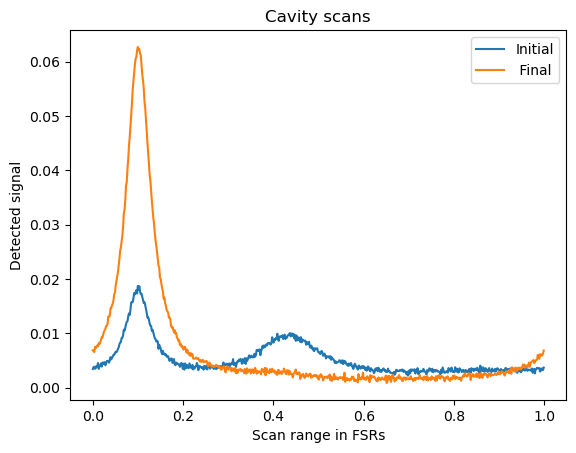

In [213]:
out.plot_cavity_scans();

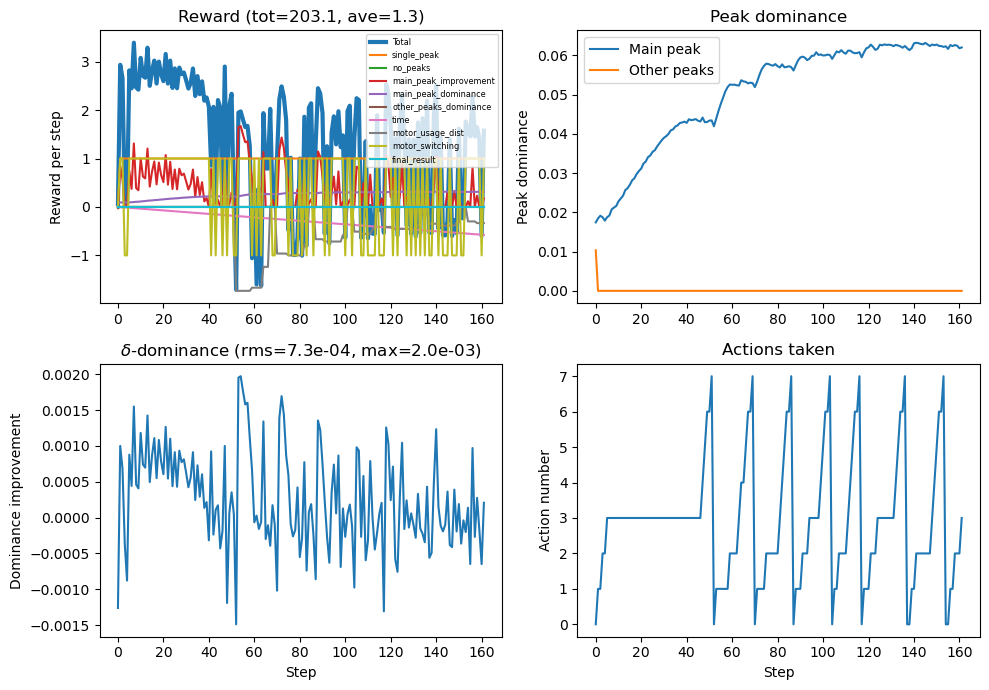

In [214]:
fig = out.plot_metrics(step_highlim=-1)

## Manual alignment
For human benchmarking

In [390]:
def manual_episode_init(
    env : CavityAlignmentEnv,
    quiet : bool = False
) -> EpisodeResultsDict:
    """
    Initialise an episode with manual alignment for benchmarking.
    
    Parameters
    ----------
    env : CavityAlignmentEnv
        `CavityAlignmentEnv` instance that has the gymnasium environment for the cavity model under test.
        Usually can be created using the factory method created by `calmly.get_env_factory()`
    quiet : bool
        If `True`, no output is provided to stdout. Default is `False`.

    Returns
    -------
    EpisodeResultsDict
        Dictionary containing results and metrics, plus some visualisation methods. 
    """
    obs, info = env.reset()
    terminated = False
    truncated = False
    episode_reward = 0.0
    rewards =[]
    action_list = []
    dominance_list = []
    r_dominance_list = []
    delta_dominance_list = []
    
    observations = [obs]
    infos = [info]
    
    reward_components = {}
    for rc in env.reward_component_keys:
        reward_components[rc] = []

    out = {
        'terminated' : terminated,
        'truncated' : truncated,
        'episode_reward' : episode_reward,
        'rewards' : rewards,
        'action_list' : action_list,
        'dominance_list' : dominance_list,
        'r_dominance_list' : r_dominance_list,
        'delta_dominance_list' : delta_dominance_list,
        'reward_components' : reward_components,
        'observations' : observations,
        'infos' : infos
    }

    if not quiet:
        reward = None
        print('step:', env._steps_taken, '\trew:', reward, '\tdom:', env._cur_dominance, \
              '\tddom:', env._cur_delta_dominance, '\tNpeaks:', info['Npeaks_found'])
    return EpisodeResultsDict(out)
    

def manual_episode_step(
    env : CavityAlignmentEnv,
    diag : EpisodeResultsDict,
    action : int = None,
    quiet : bool = False
):
    """
    Take an action in an episode with manual alignment. If no `action` is given, will print the results of the last action.

    Parameters
    ----------
    env : CavityAlignmentEnv
        `CavityAlignmentEnv` instance that has the gymnasium environment for the cavity model under test.
    diag : EpisodeResultsDict
        Dictionary containing results and metrics, plus some visualisation methods. 
        This dictionary is normally returned by `manual_episode_init()`.
    action : int
        Number of the action to take.
        Default is `None`, which takes no action but prints the results of the last one (unless `quiet` is `True`).
    quiet : bool
        If `True`, no output is provided to stdout. Default is `False`.
    """
    if (action is None) and (not quiet):
        # Just print out the last results
        obs, info = env._get_obs_and_info()
        reward = None
        print('step:', env._steps_taken, '\trew:', reward, '\tdom:', env._cur_dominance, \
              '\tddom:', env._cur_delta_dominance, '\tNpeaks:', info['Npeaks_found'])
    elif action is not None:
        if diag['terminated'] or diag['truncated']:
            raise ValueError('Alignment has already been completed')
        # Take the action
        obs, reward, terminated, truncated, info = env.step(int(action))
        
        diag['terminated'] = terminated
        diag['truncated'] = truncated
        diag['episode_reward'] += reward
        diag['rewards'].append(reward)
        diag['action_list'].append(action)
        diag['dominance_list'].append(env._cur_dominance)
        diag['r_dominance_list'].append(env._cur_r_dominance)
        diag['delta_dominance_list'].append(env._cur_delta_dominance)
        for rc in env.reward_component_keys:
            diag['reward_components'][rc].append(info.get('reward/'+rc, 0))
        diag['observations'].append(obs)
        diag['infos'].append(info)

        if not quiet:
            if terminated:
                print("======TERMINATED======")
            if truncated:
                print("======TRUNCATED=======") 
            print('step:', env._steps_taken, '\trew:', reward, '\tdom:', env._cur_dominance, \
                  '\tddom:', env._cur_delta_dominance, '\tNpeaks:', info['Npeaks_found'])
        return


In [391]:
test_env = make_env()()
diag = manual_episode_init(test_env)

step: 0 	rew: None 	dom: 0.3307056408478223 	ddom: None 	Npeaks: 1


In [412]:
manual_episode_step(test_env, diag, action=0)

ValueError: Alignment is already completed

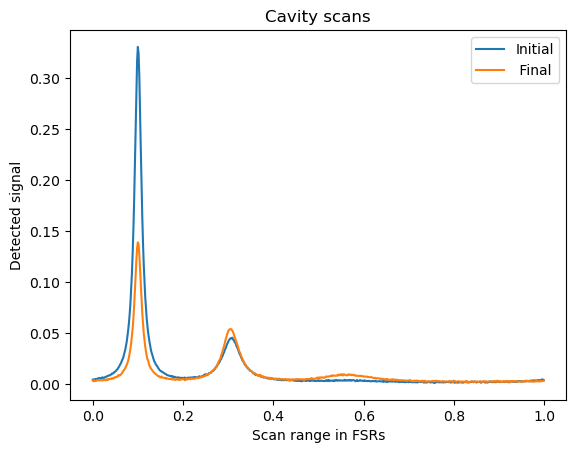

In [414]:
diag.plot_cavity_scans();

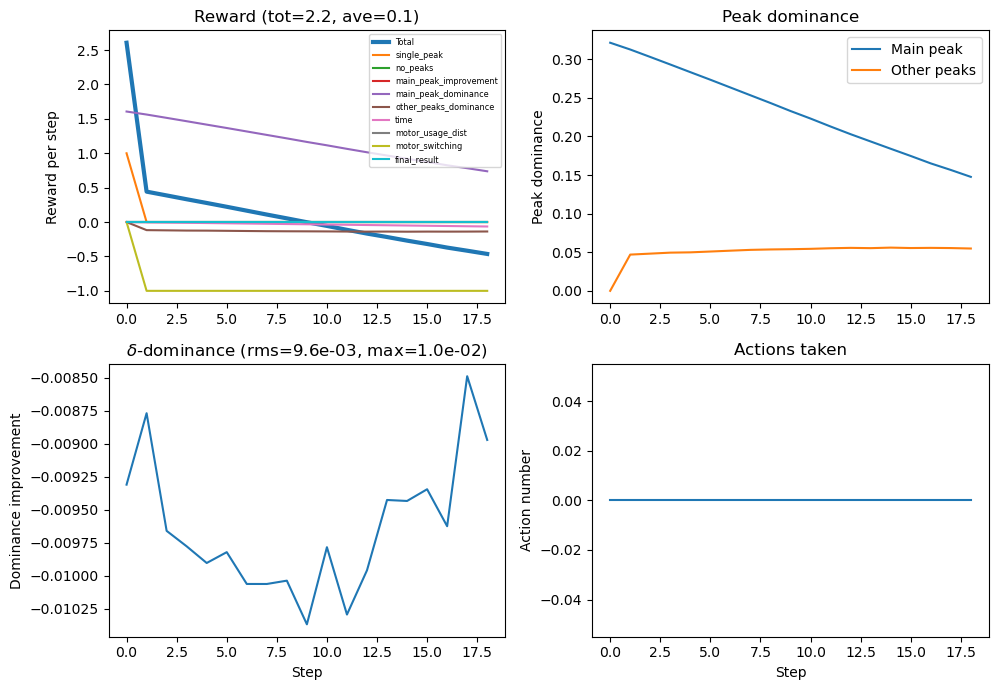

In [415]:
diag.plot_metrics(step_highlim=-1);

## Simple heuristic script
The actual algorithm is very simple and is encoded in the `iterative_policy()` function.

In [423]:
def make_heuristic_env():
    return get_env_factory(
        cav_sim_factory=cav_sim_factory,
        scan_processor_factory=scan_processor_factory,
        monitor=False,
        training=False,
        mis_angle_min=-2.5e-4,
        mis_angle_max=2.5e-4
    )()

def iterative_policy(obs):
    """
    This is a simple heuristic algorithm which mimics the standard manual iterative process for aligning an optical cavity.
    The algorithm goes through all motors consequitively:
    0. Select motor 0.
    1. Move the selected motor in some direction.
    2. If the alignment worsened, move the same motor in the opposite direction.
    3. Repeat the last action until the alignment stops improving.
    4. Switch to the next motor.
    """
    last_motor_index = np.where(obs["last_motor_vector"])[0][0] if sum(obs["last_motor_vector"])>0 else None
    last_motor_dir_mod = obs["last_motor_direction"][0]/2 + 0.5 # {-1,1}->{0,1}
    if last_motor_index is None:
        new_action = 0
    else:
        last_action = int(2*last_motor_index+last_motor_dir_mod)

        if obs["cur_delta_dominance"] < 0:
            new_action = last_action + 1 if last_action != 7 else 0
        else:
            new_action = last_action
    
    return new_action

In [424]:
test_env = make_heuristic_env()
out = simulate_episode_with_trained_model(iterative_policy, test_env)

step: 50 	rew: 3.990366938134855 	dom: 0.39344724469949915 	ddom: 0.00023493848082828395 	Npeaks: 1
step: 100 	rew: 5.059632605177447 	dom: 0.4553112394620948 	ddom: 0.0013450533304307233 	Npeaks: 1
step: 150 	rew: 4.740947533376101 	dom: 0.5071246916430106 	ddom: 0.0008739648396838273 	Npeaks: 1
step: 200 	rew: 3.5386707495622054 	dom: 0.5415470484809596 	ddom: -0.0006974796978620468 	Npeaks: 1
step: 250 	rew: 4.054391156234989 	dom: 0.5483650177283748 	ddom: 0.000595352996989984 	Npeaks: 1
step: 300 	rew: 4.517544257191342 	dom: 0.5557849655868271 	ddom: 0.0012202858308664188 	Npeaks: 1
Total Episode Reward: 1606.0091413024822
Finished as Terminated after 321 steps
Final dominance of the main peak: 0.5539438625021201


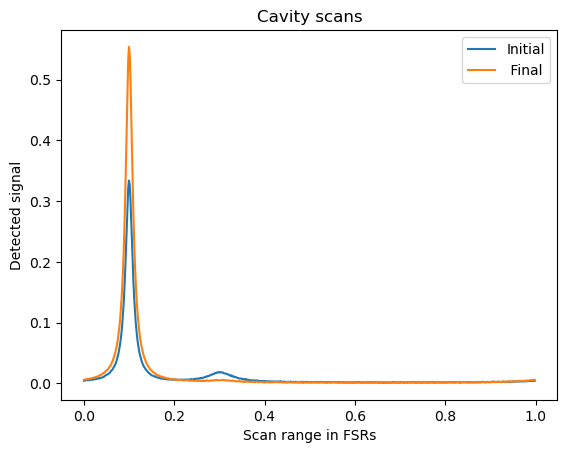

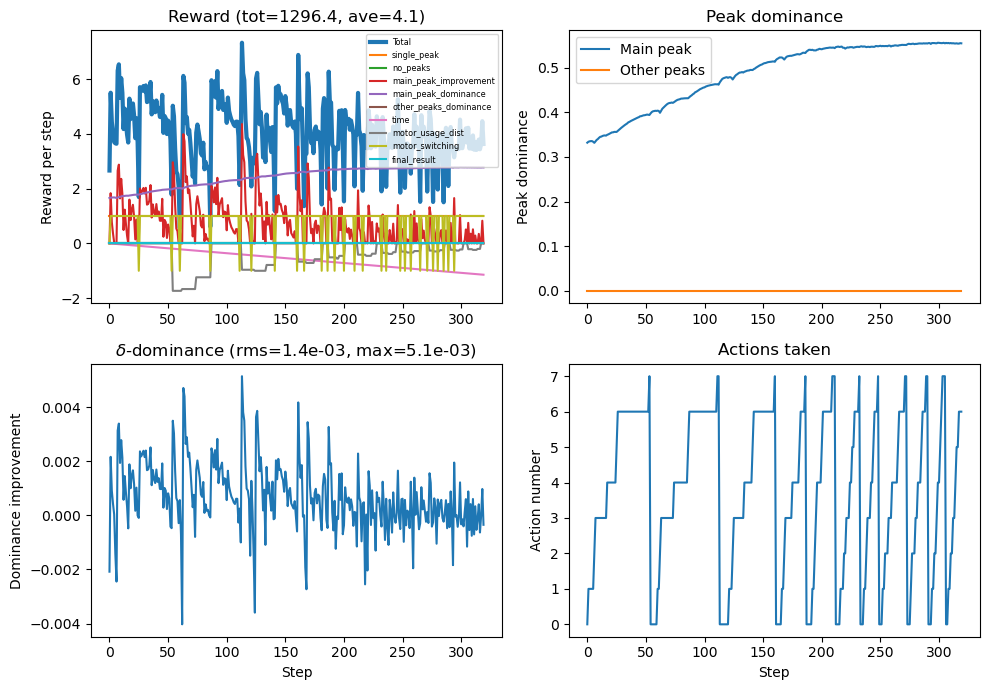

In [425]:
out.plot_cavity_scans();
out.plot_metrics(step_highlim=-1);

## Heuristic data collection for Behavioural Cloning
creating a dataset using the heuristic engine for use in BC

In [1]:

def collect_data_with_policy(
    env_fn : Callable[[None], CavityAlignmentEnv],
    policy_fn : Callable[[dict],int],
    save_path : str,
    n_episodes : int = 100,
    quiet : bool = False
):
    """
    This function creates a dataset that contains the simulation results for
    `n_episodes` of aligning the optical cavity given by the environment factory `env_fn`
    using the given policy `policy_fn` and stores it in a file.
    
    Parameters
    ----------
    env_fn : Callable[[None], CavityAlignmentEnv],
    policy_fn : Callable[[dict],int],
    save_path : str,
    n_episodes : int = 100,
    quiet : bool = False
    """
    dataset = []

    episode_iterator = tqdm.tqdm(range(n_episodes)) if not quiet else range(n_episodes)
    for ep in episode_iterator:
        env = env_fn()
        obs, info = env.reset()

        step_count = 0

        while True:
            action = policy_fn(obs)
            dataset.append((obs, action))

            obs, reward, terminated, truncated, info = env.step(action)
            step_count += 1
            if terminated or truncated:
                break

        env.close()

    print(f"Saving dataset with {len(dataset)} samples to {save_path}...")
    with open(save_path, 'wb') as f:
        pickle.dump(dataset, f)
    print("Dataset saved.")

NameError: name 'Callable' is not defined

In [421]:
collect_data_with_policy(
    env_fn=make_heuristic_env,
    policy_fn=heuristic_policy,
    save_path="testt.pkl",
    n_episodes=5
)

100%|██████████████████████████████████████████████████████████| 5/5 [00:11<00:00,  2.35s/it]

Saving dataset with 618 samples to testt.pkl...
Dataset saved.


## Behavioural Cloning
Obtaining a PPO-compatible policy by training a BC model with the heuristic dataset

In [422]:
with open("heuristic_dataset.pkl", "rb") as f:
    data = pickle.load(f)

obs_list, acts_list = zip(*data)  # Each obs is a dict

obs_dict_np = {
    key: np.array([obs[key] for obs in obs_list], dtype=np.float32)
    for key in obs_list[0].keys()
}
obs = DictObs(obs_dict_np)
actions = np.array(acts_list)

dummy_length = len(actions)
empty_infos = [{} for _ in range(dummy_length)]
empty_dones = np.zeros(dummy_length, dtype=bool)
empty_next_obs = obs  # Not used for BC

# Construct transitions
transitions = Transitions(
    obs=obs,
    acts=actions,
    infos=empty_infos,
    dones=empty_dones,
    next_obs=empty_next_obs,
)

In [ ]:
rng = np.random.default_rng(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
torch.set_num_threads(10)

num_envs = 4

# Create a vectorized environment (DQN works best with single environments)
envs = DummyVecEnv([make_env(training=True, monitor=True, Nmisalign=1, algo='DQN') for _ in range(num_envs)])

custom_policy = PPOMultiInputPolicy(
    observation_space=env_dqn.observation_space,
    action_space=env_dqn.action_space,
    lr_schedule=lambda _: 1e-4,
    net_arch=[64, 64]
)

# bc_trainer = BC(
#     observation_space=env_dqn.observation_space,
#     action_space=env_dqn.action_space,
#     demonstrations=transitions,
#     rng=np.random.default_rng(),
#     policy_class="MultiInputPolicy",
#     policy_kwargs=policy_kwargs,
#     device=device,
# )

bc_trainer = BC(
    policy=custom_policy,
    observation_space=env_dqn.observation_space,
    action_space=env_dqn.action_space,
    demonstrations=transitions,
    rng=np.random.default_rng(),
    device=device
)

bc_trainer.train(n_epochs=10)

torch.save(bc_trainer.policy.state_dict(), "bc_policy_dqn_6464_1.pt")

## PPO training enabled by BC
loading the BC policy into a PPO model for further training

In [ ]:
num_envs = 10
envs = SubprocVecEnv([make_env(training=True, monitor=True) for _ in range(num_envs)])

model = PPO("MultiInputPolicy", envs, verbose=1, tensorboard_log="./ppo_tensorboard/", ent_coef=0.02)
model.policy.load_state_dict(torch.load("bc_policy_dqn_6464.pt"))
model.learn(total_timesteps=400_000, progress_bar=True,tb_log_name="PPO_MultiEnv")
model.save("ppo_training")

## Class hierarchy

| Class name | Group | Functionality | Dependants | Objects used in |
|------------|-------|---------------|------------|-----------------|
|`MirrorImage` | Simulation | Drawing beam spots on mirrors | `MirrorAt45` | - |
|`MirrorAt45` | Simulation | Mirror description for the geometric model | - | `RectangularCavity` |
|`finesse.Model` | Simulation | (External) Finesse cavity model for scans | - | - |
|`RectangularCavity` | Simulation | Cavity description, interaction methods | - | - |